# Simultaneous fits for Dpi and DK

## 1) Set up

In [31]:
# Standard Library Imports
import os
import time
import numpy as np
import uproot
import matplotlib.pyplot as plt
# ROOT and RooFit Imports
import ROOT
from ROOT import RooFit as RF
from ROOT import (
    kBlue, kRed, kViolet, kMagenta, kOrange, kGreen, kBlack,
    kAzure, kFullCircle, kDashed, kDotted, kDashDotted
)
# IPython Display Utilities
from IPython.display import Image as IPyImage, display as ipydisplay
# ROOT Configuration
ROOT.gROOT.SetBatch(True)       # Run ROOT in batch mode (no GUI)
ROOT.EnableImplicitMT()         # Enable multi-threading
# Load Custom Library and Include Paths
# Load custom HILL/HORNS PDFs (once)
base = os.path.expandvars("$HOME/roohill/standalone")
ROOT.gInterpreter.AddIncludePath(os.path.join(base, "include"))
ROOT.gSystem.Load(os.path.join(base, "libRooHILLdini.so"))
ROOT.gSystem.Load(os.path.join(base, "libRooHORNSdini.so"))
print("Custom PDFs:", hasattr(ROOT, "RooHILLdini"), hasattr(ROOT, "RooHORNSdini"))


Custom PDFs: True True



## 2) Setting up data

#### i) read Bd -- > Dpi and Bd --> DK 
##### check runs MagUp 308104 - 308540
##### check runs MagDown 307589 - 308098

In [32]:
# optional progress bar
try:
    from tqdm import tqdm
except ImportError:
    def tqdm(it, **kw):  # fallback if tqdm is missing
        return it

In [33]:
# tree location inside each ROOT file
TREE_PATH = "Tuple/DecayTree"
# input files
# Input files
DPI_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_down_final_block7.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DPi/SelectedData/Bd2DPi_24c4_up_final_block8.root",
]
DK_FILES = [
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_down_final.root",
    "/eos/lhcb/wg/b2oc/XS_b2X_EM_2022/Bd2DK/SelectedData/2024/Bd2DK_24c4a_up_final.root",
]

# sanity check: ensure all input files exist
assert all(os.path.exists(f) for f in DPI_FILES + DK_FILES), "Missing input ROOT files."

In [34]:
def check_runnumbers(files, tree_path=TREE_PATH, max_print=8):
    print("\n🔍 Checking RUNNUMBER coverage:")
    for fp in files:
        if not os.path.exists(fp):
            print(f"  [Missing] {fp}")
            continue
        try:
            with uproot.open(f"{fp}:{tree_path}") as tree:
                runnums = tree["RUNNUMBER"].array(library="np")
                if runnums.size == 0:
                    print(f"\nFile: {os.path.basename(fp)} — no events found.")
                    continue

                unique_runs = np.unique(runnums)
                n_total = len(runnums)
                n_unique = len(unique_runs)
                rmin, rmax = np.min(unique_runs), np.max(unique_runs)

                print(f"\nFile: {os.path.basename(fp)}")
                print(f"  Total events:  {n_total:,}")
                print(f"  Unique runs:   {n_unique}")
                print(f"  Run range:     {rmin} → {rmax}")
                if n_unique <= max_print:
                    print(f"  All run numbers: {unique_runs}")
                else:
                    print(f"  First few run numbers: {unique_runs[:max_print]} ...")
        except Exception as e:
            print(f"  [Error reading {fp}: {e}]")
# Run checks for both channels
check_runnumbers(DPI_FILES)
check_runnumbers(DK_FILES)


🔍 Checking RUNNUMBER coverage:

File: Bd2DPi_24c4_down_final_block7.root
  Total events:  1,956,966
  Unique runs:   289
  Run range:     307589 → 308098
  First few run numbers: [307589 307590 307591 307592 307593 307594 307595 307596] ...

File: Bd2DPi_24c4_up_final_block8.root
  Total events:  1,179,814
  Unique runs:   182
  Run range:     308104 → 308540
  First few run numbers: [308104 308105 308107 308143 308144 308145 308146 308152] ...

🔍 Checking RUNNUMBER coverage:

File: Bd2DK_24c4a_down_final.root
  Total events:  543,117
  Unique runs:   277
  Run range:     307589 → 308098
  First few run numbers: [307589 307590 307591 307592 307593 307594 307595 307596] ...

File: Bd2DK_24c4a_up_final.root
  Total events:  327,189
  Unique runs:   169
  Run range:     308105 → 308540
  First few run numbers: [308105 308107 308144 308145 308146 308153 308154 308155] ...



#### ii) Histogram settings

In [35]:
# histogram settings (Bd mass)
NBINS = 300
mmin, mmax = 4950.0, 6000.0  # MeV

## 3) Cuts investigation + application

### a) Investigation

In [36]:
# TEST VALUES
# D mass / window (applies to both channels)
D_MASS   = 1869.65  # MeV
D_WINDOW = 20.0     # MeV

# common vertex-quality cuts
B_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5
D_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5

# bachelor PIDK thresholds (the only difference between channels)
BACHELOR_PIDK_MAX = -5.0  # Dπ requires PIDK < 0  (pion-like)
BACHELOR_PIDK_MIN = 5.0  # DK requires  PIDK > 5  (kaon-like)

# common flight/IP/pointing & MVA cuts
B_FDCHI2_MIN = 70.0 # WAS 100
B_IPCHI2_MAX = 15.0 # WAS 15.0
B_DIRA_MIN   = 0.992
MVA_BRANCH   = "lab0_MVA"
MVA_CUT      = 0.9

#### i) Vertex quality B and D

In [37]:
B_MASS, SIG_WIN = 5279.65, 30.0
SB_LEFT, SB_RIGHT = (mmin, B_MASS - 80.0), (B_MASS + 80.0, mmax)
BACHELOR_PIDK_MAX, BACHELOR_PIDK_MIN = 0.0, 5.0  # Dπ < 0, DK > 5
# Scan grids
BCHI_GRID = np.round(np.arange(5.0, 10.0 + 1e-9, 0.25), 2)   # B vertex scan
DCHI_GRID = np.round(np.arange(1.0, 10.0 + 1e-9, 0.25), 2)   # D vertex scan
# Punzi FOM
PUNZI_A = 3.0
def fom_punzi(S, B, a=PUNZI_A): return S / (0.5*a + np.sqrt(max(0.0, B)))
# ---------- branches & loaders ----------
BR = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab0_BPVFDCHI2","lab0_BPVIPCHI2","lab0_BPVDIRA", MVA_BRANCH
]
def load_arrays(files, mode):
    """Apply all common cuts EXCEPT the vertex chi2/ndf cuts; return mB, bchi, dchi arrays."""
    assert mode in ("Dpi","DK")
    mB_ls, bchi_ls, dchi_ls = [], [], []
    for arr in tqdm(uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                                   expressions=BR, step_size="60 MB",
                                   library="np", allow_missing=False),
                    desc=f"Load ({mode})"):
        mB, bchi, dchi, mD, pidk = arr["lab0_MASS"], arr["lab0_END_VCHI2DOF"], arr["lab2_END_VCHI2DOF"], arr["lab2_MASS"], arr["lab1_PIDK"]
        fdchi2, ipchi2, dira, mva = arr["lab0_BPVFDCHI2"], arr["lab0_BPVIPCHI2"], arr["lab0_BPVDIRA"], arr[MVA_BRANCH]

        finite = (np.isfinite(mB)&np.isfinite(bchi)&np.isfinite(dchi)&np.isfinite(mD)&
                  np.isfinite(pidk)&np.isfinite(fdchi2)&np.isfinite(ipchi2)&np.isfinite(dira)&np.isfinite(mva))
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )
        base = (
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
            # No bchi/dchi cuts here — we want their shapes for scanning
        )
        pid  = (pidk < BACHELOR_PIDK_MAX) if mode=="Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base & pid & (mB > mmin) & (mB < mmax)

        if np.any(sel):
            mB_ls.append(mB[sel]); bchi_ls.append(bchi[sel]); dchi_ls.append(dchi[sel])

    if not mB_ls:
        return np.array([]), np.array([]), np.array([])
    return np.concatenate(mB_ls), np.concatenate(bchi_ls), np.concatenate(dchi_ls)
# Load once per channel; combine
mB_dpi, bchi_dpi, dchi_dpi = load_arrays(DPI_FILES, "Dpi")
mB_dk,  bchi_dk,  dchi_dk  = load_arrays(DK_FILES,  "DK")
cache = {
    "Dπ":  {"mB": mB_dpi, "bchi": bchi_dpi, "dchi": dchi_dpi},
    "DK":  {"mB": mB_dk,  "bchi": bchi_dk,  "dchi": dchi_dk },
    "All": {"mB": np.concatenate([mB_dpi, mB_dk]),
            "bchi": np.concatenate([bchi_dpi, bchi_dk]),
            "dchi": np.concatenate([dchi_dpi, dchi_dk])},
}
# ---------- S/B estimate ----------
def count_S_B(masses):
    sig_lo, sig_hi = B_MASS - SIG_WIN, B_MASS + SIG_WIN
    sb1_lo, sb1_hi = SB_LEFT; sb2_lo, sb2_hi = SB_RIGHT
    S  = np.sum((masses>=sig_lo)&(masses<=sig_hi))
    SB = np.sum((masses>=sb1_lo)&(masses<=sb1_hi)) + np.sum((masses>=sb2_lo)&(masses<=sb2_hi))
    sig_w = sig_hi - sig_lo
    sb_w  = (sb1_hi - sb1_lo) + (sb2_hi - sb2_lo)
    Bpred = (SB/sb_w)*sig_w if sb_w>0 else 0.0
    return float(S), float(Bpred)

def scan(sample, values, grid):
    rows = []
    for thr in grid:
        keep = values < thr
        S, B = count_S_B(sample["mB"][keep])
        F = fom_punzi(S, B)
        rows.append((thr, S, B, F))
    arr = np.array(rows, dtype=[("thr", float), ("S", float), ("B", float), ("F", float)])
    best = arr[np.argmax(arr["F"])] if arr.size else np.array((np.nan,0,0,0), dtype=arr.dtype)
    return arr, best

# ---------- Scan B-vertex and D-vertex (report per channel + combined) ----------
print("=== Scan B-vertex χ²/ndf (lab0_END_VCHI2DOF) ===")
bestB = {}
for name in ("Dπ","DK","All"):
    _, best = scan(cache[name], cache[name]["bchi"], BCHI_GRID)
    bestB[name] = best
    print(f"{name}: best thr = {best['thr']:.2f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

print("\n=== Scan D-vertex χ²/ndf (lab2_END_VCHI2DOF) ===")
bestD = {}
for name in ("Dπ","DK","All"):
    _, best = scan(cache[name], cache[name]["dchi"], DCHI_GRID)
    bestD[name] = best
    print(f"{name}: best thr = {best['thr']:.2f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

# Use the COMBINED best thresholds for the plot cut lines:
CUT_B = float(bestB["All"]["thr"])
CUT_D = float(bestD["All"]["thr"])
print(f"\nPlot cut lines (combined best):  B cut = {CUT_B:.2f},  D cut = {CUT_D:.2f}")


Load (Dpi): 3it [00:42, 14.11s/it]
Load (DK): 2it [00:11,  5.52s/it]



=== Scan B-vertex χ²/ndf (lab0_END_VCHI2DOF) ===
Dπ: best thr = 10.00   S=821407   B~=68567.7   FOM=3119.019
DK: best thr = 10.00   S=80330   B~=10255.8   FOM=781.643
All: best thr = 10.00   S=901737   B~=78823.4   FOM=3194.759

=== Scan D-vertex χ²/ndf (lab2_END_VCHI2DOF) ===
Dπ: best thr = 10.00   S=823763   B~=68743.6   FOM=3123.984
DK: best thr = 7.50   S=80078   B~=10147.2   FOM=783.286
All: best thr = 9.00   S=903078   B~=78805.6   FOM=3199.870

Plot cut lines (combined best):  B cut = 10.00,  D cut = 9.00



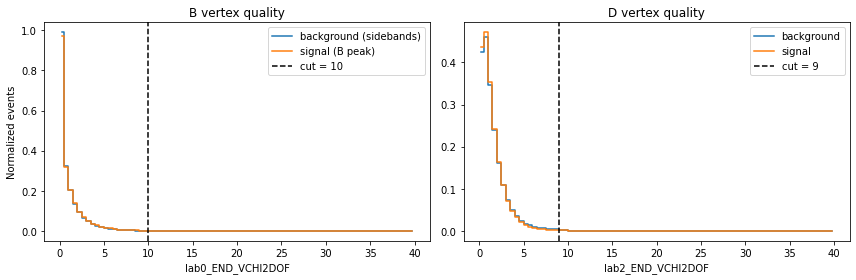

In [38]:
# ---------- Plot shapes with those best cut lines ----------
BINS = np.linspace(0, 40, 81)
mB_all   = cache["All"]["mB"]
bchi_all = cache["All"]["bchi"]
dchi_all = cache["All"]["dchi"]
sig_mask = (np.abs(mB_all - B_MASS) < SIG_WIN)
bkg_mask = ((mB_all > SB_LEFT[0]) & (mB_all < SB_LEFT[1])) | ((mB_all > SB_RIGHT[0]) & (mB_all < SB_RIGHT[1]))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# B vertex
h_sig,_ = np.histogram(bchi_all[sig_mask], bins=BINS, density=True)
h_bkg,_ = np.histogram(bchi_all[bkg_mask], bins=BINS, density=True)
c = 0.5*(BINS[:-1]+BINS[1:])
axs[0].step(c, h_bkg, where="mid", label="background (sidebands)")
axs[0].step(c, h_sig, where="mid", label="signal (B peak)")
axs[0].axvline(CUT_B, ls="--", color="k", label=f"cut = {CUT_B:g}")
axs[0].set_title("B vertex quality")
axs[0].set_xlabel(r"lab0_END_VCHI2DOF")
axs[0].set_ylabel("Normalized events"); axs[0].legend()

# D vertex
h_sig,_ = np.histogram(dchi_all[sig_mask], bins=BINS, density=True)
h_bkg,_ = np.histogram(dchi_all[bkg_mask], bins=BINS, density=True)
axs[1].step(c, h_bkg, where="mid", label="background")
axs[1].step(c, h_sig, where="mid", label="signal")
axs[1].axvline(CUT_D, ls="--", color="k", label=f"cut = {CUT_D:g}")
axs[1].set_title("D vertex quality")
axs[1].set_xlabel(r"lab2_END_VCHI2DOF"); axs[1].legend()

plt.tight_layout(); plt.show()

#### ii) Flight distance significance

In [39]:
# ---- FDχ² scan grid (edit as desired) ----
FDCHI2_GRID = np.arange(20.0, 401.0, 10.0)  # scan >20 .. >400 in steps of 10
# FOM: Punzi
PUNZI_A = 3.0
def fom_punzi(S, B, a=PUNZI_A): return S / (0.5*a + np.sqrt(max(0.0, B)))
# ---------- branches & loader (exclude FDχ² cut here) ----------
BR = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab0_BPVFDCHI2","lab0_BPVIPCHI2","lab0_BPVDIRA", MVA_BRANCH
]
def load_arrays(files, mode):
    """Apply all cuts EXCEPT the FDχ² requirement; return arrays (mB, fdchi2)."""
    assert mode in ("Dpi","DK")
    mB_ls, fd_ls = [], []
    for arr in tqdm(uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                                   expressions=BR, step_size="60 MB",
                                   library="np", allow_missing=False),
                    desc=f"Load ({mode})"):
        mB, bchi, dchi, mD, pidk = arr["lab0_MASS"], arr["lab0_END_VCHI2DOF"], arr["lab2_END_VCHI2DOF"], arr["lab2_MASS"], arr["lab1_PIDK"]
        fdchi2, ipchi2, dira, mva = arr["lab0_BPVFDCHI2"], arr["lab0_BPVIPCHI2"], arr["lab0_BPVDIRA"], arr[MVA_BRANCH]

        finite = (np.isfinite(mB)&np.isfinite(bchi)&np.isfinite(dchi)&np.isfinite(mD)&
                  np.isfinite(pidk)&np.isfinite(fdchi2)&np.isfinite(ipchi2)&np.isfinite(dira)&np.isfinite(mva))
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )
        # common cuts (EXCLUDE fdchi2 here)
        base = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )
        pid = (pidk < BACHELOR_PIDK_MAX) if mode=="Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base & pid & (mB > mmin) & (mB < mmax)

        if np.any(sel):
            mB_ls.append(mB[sel]); fd_ls.append(fdchi2[sel])

    if not mB_ls:
        return np.array([]), np.array([])
    return np.concatenate(mB_ls), np.concatenate(fd_ls)
# Load once per channel; combine
mB_dpi, fd_dpi = load_arrays(DPI_FILES, "Dpi")
mB_dk,  fd_dk  = load_arrays(DK_FILES,  "DK")
cache = {
    "Dπ":  {"mB": mB_dpi, "fd": fd_dpi},
    "DK":  {"mB": mB_dk,  "fd": fd_dk },
    "All": {"mB": np.concatenate([mB_dpi, mB_dk]),
            "fd": np.concatenate([fd_dpi, fd_dk])},
}
# ---------- S/B estimator ----------
def count_S_B(masses):
    sig_lo, sig_hi = B_MASS - SIG_WIN, B_MASS + SIG_WIN
    sb1_lo, sb1_hi = SB_LEFT; sb2_lo, sb2_hi = SB_RIGHT
    S  = np.sum((masses>=sig_lo)&(masses<=sig_hi))
    SB = np.sum((masses>=sb1_lo)&(masses<=sb1_hi)) + np.sum((masses>=sb2_lo)&(masses<=sb2_hi))
    sig_w = sig_hi - sig_lo
    sb_w  = (sb1_hi - sb1_lo) + (sb2_hi - sb2_lo)
    Bpred = (SB/sb_w)*sig_w if sb_w>0 else 0.0
    return float(S), float(Bpred)

def scan_fd(sample, fdvals, grid):
    rows = []
    for thr in grid:
        keep = fdvals > thr              # FDχ² is a MINIMUM cut
        S, B = count_S_B(sample["mB"][keep])
        F = fom_punzi(S, B)
        rows.append((thr, S, B, F))
    arr = np.array(rows, dtype=[("thr", float), ("S", float), ("B", float), ("F", float)])
    best = arr[np.argmax(arr["F"])] if arr.size else np.array((np.nan,0,0,0), dtype=arr.dtype)
    return arr, best
# ---------- scan and plot ----------
print("=== Scan Flight-distance χ² (lab0_BPVFDCHI2 > threshold) ===")
results = {}
for name in ("Dπ","DK","All"):
    arr, best = scan_fd(cache[name], cache[name]["fd"], FDCHI2_GRID)
    results[name] = (arr, best)
    print(f"{name}: best thr = {best['thr']:.1f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

Load (Dpi): 3it [00:02,  1.33it/s]
Load (DK): 2it [00:00,  2.44it/s]



=== Scan Flight-distance χ² (lab0_BPVFDCHI2 > threshold) ===
Dπ: best thr = 40.0   S=825298   B~=69171.3   FOM=3120.168
DK: best thr = 120.0   S=78793   B~=9815.1   FOM=783.457
All: best thr = 60.0   S=903804   B~=79172.0   FOM=3195.064



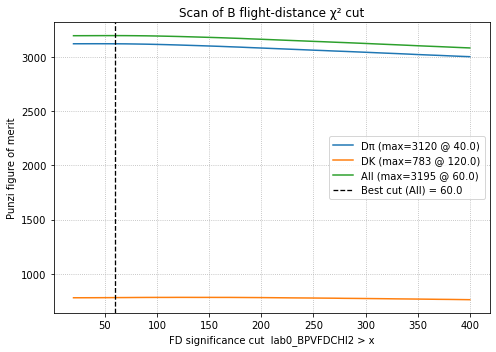

In [40]:
# ---------- plot Punzi FOM vs threshold ----------
plt.figure(figsize=(7,5))
for name, (arr, best) in results.items():
    plt.plot(arr["thr"], arr["F"], label=f"{name} (max={best['F']:.0f} @ {best['thr']:.1f})")
plt.axvline(results["All"][1]["thr"], color="k", ls="--", lw=1.3, label=f"Best cut (All) = {results['All'][1]['thr']:.1f}")
plt.xlabel(r"FD significance cut  lab0_BPVFDCHI2 > x")
plt.ylabel("Punzi figure of merit")
plt.title("Scan of B flight-distance χ² cut")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

#### iii) Impact parameter significance

In [41]:
IPCHI2_GRID = np.round(np.arange(2.0, 40.0 + 1e-9, 0.5), 2)
def fom_punzi(S, B, a=PUNZI_A): return S / (0.5*a + np.sqrt(max(0.0, B)))
# ---------- branches & loader (exclude IPχ² cut here) ----------
BR = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab0_BPVFDCHI2","lab0_BPVIPCHI2","lab0_BPVDIRA", MVA_BRANCH
]
def load_arrays(files, mode):
    """Apply all cuts EXCEPT the IPχ² requirement; return arrays (mB, ipchi2)."""
    assert mode in ("Dpi","DK")
    mB_ls, ip_ls = [], []
    for arr in tqdm(uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                                   expressions=BR, step_size="60 MB",
                                   library="np", allow_missing=False),
                    desc=f"Load ({mode})"):
        mB, bchi, dchi, mD, pidk = arr["lab0_MASS"], arr["lab0_END_VCHI2DOF"], arr["lab2_END_VCHI2DOF"], arr["lab2_MASS"], arr["lab1_PIDK"]
        fdchi2, ipchi2, dira, mva = arr["lab0_BPVFDCHI2"], arr["lab0_BPVIPCHI2"], arr["lab0_BPVDIRA"], arr[MVA_BRANCH]

        finite = (np.isfinite(mB)&np.isfinite(bchi)&np.isfinite(dchi)&np.isfinite(mD)&
                  np.isfinite(pidk)&np.isfinite(fdchi2)&np.isfinite(ipchi2)&np.isfinite(dira)&np.isfinite(mva))
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )
        # common cuts (EXCLUDE ipchi2 here)
        base = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )
        pid = (pidk < BACHELOR_PIDK_MAX) if mode=="Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base & pid & (mB > mmin) & (mB < mmax)

        if np.any(sel):
            mB_ls.append(mB[sel]); ip_ls.append(ipchi2[sel])
    if not mB_ls:
        return np.array([]), np.array([])
    return np.concatenate(mB_ls), np.concatenate(ip_ls)
# Load once per channel; combine
mB_dpi, ip_dpi = load_arrays(DPI_FILES, "Dpi")
mB_dk,  ip_dk  = load_arrays(DK_FILES,  "DK")
cache = {
    "Dπ":  {"mB": mB_dpi, "ip": ip_dpi},
    "DK":  {"mB": mB_dk,  "ip": ip_dk },
    "All": {"mB": np.concatenate([mB_dpi, mB_dk]),
            "ip": np.concatenate([ip_dpi, ip_dk])},
}
# ---------- S/B estimator ----------
def count_S_B(masses):
    sig_lo, sig_hi = B_MASS - SIG_WIN, B_MASS + SIG_WIN
    sb1_lo, sb1_hi = SB_LEFT; sb2_lo, sb2_hi = SB_RIGHT
    S  = np.sum((masses>=sig_lo)&(masses<=sig_hi))
    SB = np.sum((masses>=sb1_lo)&(masses<=sb1_hi)) + np.sum((masses>=sb2_lo)&(masses<=sb2_hi))
    sig_w = sig_hi - sig_lo
    sb_w  = (sb1_hi - sb1_lo) + (sb2_hi - sb2_lo)
    Bpred = (SB/sb_w)*sig_w if sb_w>0 else 0.0
    return float(S), float(Bpred)

def scan_ip(sample, ipvals, grid):
    """Scan MAXIMUM cut: keep candidates with ipchi2 < thr."""
    rows = []
    for thr in grid:
        keep = ipvals < thr
        S, B = count_S_B(sample["mB"][keep])
        F = fom_punzi(S, B)
        rows.append((thr, S, B, F))
    arr = np.array(rows, dtype=[("thr", float), ("S", float), ("B", float), ("F", float)])
    best = arr[np.argmax(arr["F"])] if arr.size else np.array((np.nan,0,0,0), dtype=arr.dtype)
    return arr, best


Load (Dpi): 3it [00:01,  1.81it/s]
Load (DK): 2it [00:00,  2.34it/s]



=== Scan Impact-parameter χ² (lab0_BPVIPCHI2 < threshold) ===
Dπ: best thr = 8.00   S=775092   B~=58697.8   FOM=3179.522
DK: best thr = 9.50   S=77180   B~=9242.2   FOM=790.486
All: best thr = 8.50   S=858544   B~=68812.6   FOM=3254.261



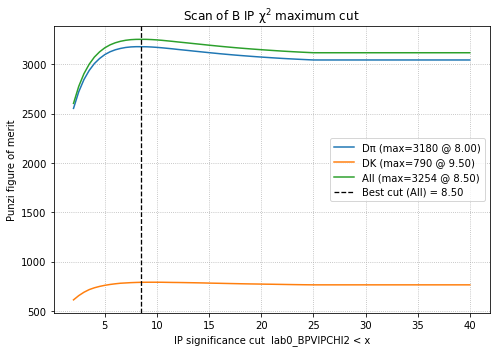

In [42]:
# ---------- scan ----------
results = {}
print("=== Scan Impact-parameter χ² (lab0_BPVIPCHI2 < threshold) ===")
for name in ("Dπ","DK","All"):
    arr, best = scan_ip(cache[name], cache[name]["ip"], IPCHI2_GRID)
    results[name] = (arr, best)
    print(f"{name}: best thr = {best['thr']:.2f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

# ---------- plot FOM vs threshold ----------
plt.figure(figsize=(7,5))
for name, (arr, best) in results.items():
    plt.plot(arr["thr"], arr["F"], label=f"{name} (max={best['F']:.0f} @ {best['thr']:.2f})")
best_thr_all = float(results["All"][1]["thr"])
plt.axvline(best_thr_all, color="k", ls="--", lw=1.3, label=f"Best cut (All) = {best_thr_all:.2f}")
plt.xlabel(r"IP significance cut  lab0_BPVIPCHI2 < x")
plt.ylabel("Punzi figure of merit")
plt.title("Scan of B IP χ$^2$ maximum cut")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

#### iv) Pointing DIRA

Load (Dpi): 3it [00:01,  1.54it/s]
Load (DK): 2it [00:00,  2.57it/s]



=== Scan Pointing (lab0_BPVDIRA > threshold) ===
Dπ: best thr = 0.99958   S=821406   B~=68567.5   FOM=3119.020
DK: best thr = 0.99500   S=80330   B~=10255.8   FOM=781.643
All: best thr = 0.99958   S=901736   B~=78823.2   FOM=3194.760



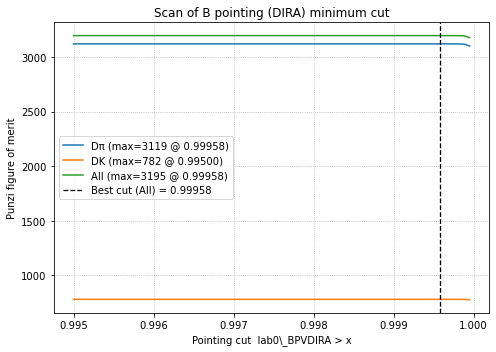

In [43]:
# Scan grid for MINIMUM DIRA cut (very close to 1.0; adjust resolution as needed)
DIRA_GRID = np.round(np.linspace(0.9950, 0.99995, 81), 5)  # ~0.00006 steps

# FOM: Punzi (a=3)
PUNZI_A = 3.0
def fom_punzi(S, B, a=PUNZI_A): return S / (0.5*a + np.sqrt(max(0.0, B)))

# ---------- branches & loader (exclude DIRA cut here) ----------
BR = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab0_BPVFDCHI2","lab0_BPVIPCHI2","lab0_BPVDIRA", MVA_BRANCH
]

def load_arrays(files, mode):
    """Apply all cuts EXCEPT the DIRA requirement; return arrays (mB, dira)."""
    assert mode in ("Dpi","DK")
    mB_ls, dira_ls = [], []
    for arr in tqdm(uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                                   expressions=BR, step_size="60 MB",
                                   library="np", allow_missing=False),
                    desc=f"Load ({mode})"):
        mB, bchi, dchi, mD, pidk = arr["lab0_MASS"], arr["lab0_END_VCHI2DOF"], arr["lab2_END_VCHI2DOF"], arr["lab2_MASS"], arr["lab1_PIDK"]
        fdchi2, ipchi2, dira, mva = arr["lab0_BPVFDCHI2"], arr["lab0_BPVIPCHI2"], arr["lab0_BPVDIRA"], arr[MVA_BRANCH]

        finite = (np.isfinite(mB)&np.isfinite(bchi)&np.isfinite(dchi)&np.isfinite(mD)&
                  np.isfinite(pidk)&np.isfinite(fdchi2)&np.isfinite(ipchi2)&np.isfinite(dira)&np.isfinite(mva))
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )

        # common cuts (EXCLUDE DIRA here)
        base = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (mva    > MVA_CUT)
        )
        pid = (pidk < BACHELOR_PIDK_MAX) if mode=="Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base & pid & (mB > mmin) & (mB < mmax)

        if np.any(sel):
            mB_ls.append(mB[sel]); dira_ls.append(dira[sel])

    if not mB_ls: return np.array([]), np.array([])
    return np.concatenate(mB_ls), np.concatenate(dira_ls)

# Load once per channel; combine
mB_dpi, dira_dpi = load_arrays(DPI_FILES, "Dpi")
mB_dk,  dira_dk  = load_arrays(DK_FILES,  "DK")
cache = {
    "Dπ":  {"mB": mB_dpi, "dira": dira_dpi},
    "DK":  {"mB": mB_dk,  "dira": dira_dk },
    "All": {"mB": np.concatenate([mB_dpi, mB_dk]),
            "dira": np.concatenate([dira_dpi, dira_dk])},
}

# ---------- S/B estimator ----------
def count_S_B(masses):
    sig_lo, sig_hi = B_MASS - SIG_WIN, B_MASS + SIG_WIN
    sb1_lo, sb1_hi = SB_LEFT; sb2_lo, sb2_hi = SB_RIGHT
    S  = np.sum((masses>=sig_lo)&(masses<=sig_hi))
    SB = np.sum((masses>=sb1_lo)&(masses<=sb1_hi)) + np.sum((masses>=sb2_lo)&(masses<=sb2_hi))
    sig_w = sig_hi - sig_lo; sb_w = (sb1_hi - sb1_lo) + (sb2_hi - sb2_lo)
    Bpred = (SB/sb_w)*sig_w if sb_w>0 else 0.0
    return float(S), float(Bpred)

def scan_dira(sample, diravals, grid):
    """Scan MINIMUM cut: keep candidates with dira > thr."""
    rows = []
    for thr in grid:
        keep = diravals > thr
        S, B = count_S_B(sample["mB"][keep])
        F = fom_punzi(S, B)
        rows.append((thr, S, B, F))
    arr = np.array(rows, dtype=[("thr", float), ("S", float), ("B", float), ("F", float)])
    best = arr[np.argmax(arr["F"])] if arr.size else np.array((np.nan,0,0,0), dtype=arr.dtype)
    return arr, best

# ---------- scan ----------
print("=== Scan Pointing (lab0_BPVDIRA > threshold) ===")
results = {}
for name in ("Dπ","DK","All"):
    arr, best = scan_dira(cache[name], cache[name]["dira"], DIRA_GRID)
    results[name] = (arr, best)
    print(f"{name}: best thr = {best['thr']:.5f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

# ---------- plot FOM vs threshold ----------
plt.figure(figsize=(7,5))
for name, (arr, best) in results.items():
    plt.plot(arr["thr"], arr["F"], label=f"{name} (max={best['F']:.0f} @ {best['thr']:.5f})")
best_thr_all = float(results["All"][1]["thr"])
plt.axvline(best_thr_all, color="k", ls="--", lw=1.3, label=f"Best cut (All) = {best_thr_all:.5f}")
plt.xlabel(r"Pointing cut  lab0\_BPVDIRA > x")
plt.ylabel("Punzi figure of merit")
plt.title("Scan of B pointing (DIRA) minimum cut")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

#### v) MVA cut

Load (Dpi): 3it [00:01,  1.76it/s]
Load (DK): 2it [00:00,  2.55it/s]



=== Scan MVA score (lab0_MVA > threshold) ===
Dπ: best thr = 0.900   S=821407   B~=68567.7   FOM=3119.019
DK: best thr = 0.900   S=80330   B~=10255.8   FOM=781.643
All: best thr = 0.900   S=901737   B~=78823.4   FOM=3194.759



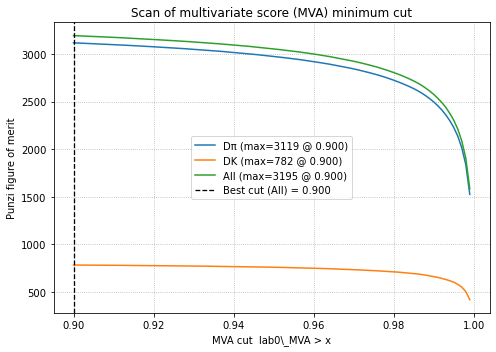

In [44]:
# Scan grid for the MINIMUM MVA cut (tune as needed)
MVA_GRID = np.round(np.linspace(0.90, 0.999, 200), 3)

# FOM: Punzi (a=3). You can switch to S/sqrt(S+B) if you prefer.
PUNZI_A = 3.0
def fom_punzi(S, B, a=PUNZI_A): return S / (0.5*a + np.sqrt(max(0.0, B)))

# ---------- branches & loader (exclude MVA cut here) ----------
BR = [
    "lab0_MASS","lab0_END_VCHI2DOF","lab2_END_VCHI2DOF","lab2_MASS","lab1_PIDK",
    "lab0_BPVFDCHI2","lab0_BPVIPCHI2","lab0_BPVDIRA", MVA_BRANCH
]

def load_arrays(files, mode):
    """Apply all cuts EXCEPT the MVA requirement; return arrays (mB, mva)."""
    assert mode in ("Dpi","DK")
    mB_ls, mva_ls = [], []
    for arr in tqdm(uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                                   expressions=BR, step_size="60 MB",
                                   library="np", allow_missing=False),
                    desc=f"Load ({mode})"):
        mB, bchi, dchi, mD, pidk = arr["lab0_MASS"], arr["lab0_END_VCHI2DOF"], arr["lab2_END_VCHI2DOF"], arr["lab2_MASS"], arr["lab1_PIDK"]
        fdchi2, ipchi2, dira, mva = arr["lab0_BPVFDCHI2"], arr["lab0_BPVIPCHI2"], arr["lab0_BPVDIRA"], arr[MVA_BRANCH]

        finite = (np.isfinite(mB)&np.isfinite(bchi)&np.isfinite(dchi)&np.isfinite(mD)&
                  np.isfinite(pidk)&np.isfinite(fdchi2)&np.isfinite(ipchi2)&np.isfinite(dira)&np.isfinite(mva))
        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )

        # common cuts (EXCLUDE MVA here)
        base = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN)
        )
        pid  = (pidk < BACHELOR_PIDK_MAX) if mode=="Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base & pid & (mB > mmin) & (mB < mmax)

        if np.any(sel):
            mB_ls.append(mB[sel]); mva_ls.append(mva[sel])

    if not mB_ls: return np.array([]), np.array([])
    return np.concatenate(mB_ls), np.concatenate(mva_ls)

# Load once per channel; combine
mB_dpi, mva_dpi = load_arrays(DPI_FILES, "Dpi")
mB_dk,  mva_dk  = load_arrays(DK_FILES,  "DK")
cache = {
    "Dπ":  {"mB": mB_dpi, "mva": mva_dpi},
    "DK":  {"mB": mB_dk,  "mva": mva_dk },
    "All": {"mB": np.concatenate([mB_dpi, mB_dk]),
            "mva": np.concatenate([mva_dpi, mva_dk])},
}

# ---------- S/B estimator ----------
def count_S_B(masses):
    sig_lo, sig_hi = B_MASS - SIG_WIN, B_MASS + SIG_WIN
    sb1_lo, sb1_hi = SB_LEFT; sb2_lo, sb2_hi = SB_RIGHT
    S  = np.sum((masses>=sig_lo)&(masses<=sig_hi))
    SB = np.sum((masses>=sb1_lo)&(masses<=sb1_hi)) + np.sum((masses>=sb2_lo)&(masses<=sb2_hi))
    sig_w = sig_hi - sig_lo; sb_w = (sb1_hi - sb1_lo) + (sb2_hi - sb2_lo)
    Bpred = (SB/sb_w)*sig_w if sb_w>0 else 0.0
    return float(S), float(Bpred)

def scan_mva(sample, mvas, grid):
    """Scan MINIMUM cut: keep candidates with mva > thr."""
    rows = []
    for thr in grid:
        keep = mvas > thr
        S, B = count_S_B(sample["mB"][keep])
        F = fom_punzi(S, B)
        rows.append((thr, S, B, F))
    arr = np.array(rows, dtype=[("thr", float), ("S", float), ("B", float), ("F", float)])
    best = arr[np.argmax(arr["F"])] if arr.size else np.array((np.nan,0,0,0), dtype=arr.dtype)
    return arr, best

# ---------- scan ----------
print("=== Scan MVA score (lab0_MVA > threshold) ===")
results = {}
for name in ("Dπ","DK","All"):
    arr, best = scan_mva(cache[name], cache[name]["mva"], MVA_GRID)
    results[name] = (arr, best)
    print(f"{name}: best thr = {best['thr']:.3f}   S={best['S']:.0f}   B~={best['B']:.1f}   FOM={best['F']:.3f}")

# ---------- plot FOM vs threshold ----------
plt.figure(figsize=(7,5))
for name, (arr, best) in results.items():
    plt.plot(arr["thr"], arr["F"], label=f"{name} (max={best['F']:.0f} @ {best['thr']:.3f})")
best_thr_all = float(results["All"][1]["thr"])
plt.axvline(best_thr_all, color="k", ls="--", lw=1.3, label=f"Best cut (All) = {best_thr_all:.3f}")
plt.xlabel(r"MVA cut  lab0\_MVA > x")
plt.ylabel("Punzi figure of merit")
plt.title("Scan of multivariate score (MVA) minimum cut")
plt.grid(True, ls=":")
plt.legend()
plt.tight_layout()
plt.show()

### b) Application

In [45]:
# D mass / window (applies to both channels)
D_MASS   = 1869.65  # MeV
D_WINDOW = 20.0     # MeV

# common vertex-quality cuts
B_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5
D_END_VCHI2DOF_MAX = 10.0 #TRY 7, used to be 5

# bachelor PIDK thresholds (the only difference between channels)
BACHELOR_PIDK_MAX = 0 # Dπ requires PIDK < 0  (pion-like)
BACHELOR_PIDK_MIN = 5 # DK requires  PIDK > 5  (kaon-like)

# common flight/IP/pointing & MVA cuts
B_FDCHI2_MIN = 70.0 # WAS 100.0, 70
B_IPCHI2_MAX = 15.0 # WAS 15.0 , 8.0
B_DIRA_MIN   = 0.9995
MVA_BRANCH   = "lab0_MVA"
MVA_CUT      = 0.9 #0.972


# branches we actually read
COMMON_BRANCHES = [
    "lab0_MASS",              # Bd mass (for histogram)
    "lab0_END_VCHI2DOF",      # B vertex chi2/dof
    "lab2_END_VCHI2DOF",      # D vertex chi2/dof
    "lab2_MASS",              # D mass (for window)
    "lab1_PIDK",              # bachelor PIDK
    "lab0_BPVFDCHI2",         # B flight-distance chi2
    "lab0_BPVIPCHI2",         # B impact-parameter chi2
    "lab0_BPVDIRA",           # B pointing angle cosine
    MVA_BRANCH,               # MVA score
]

#### iv) Build Bd samples with identical cuts except PIDK, build arrays, make histograms and save

In [46]:
# helper to build Bd mass arrays for a given mode (Dpi or DK)
def build_vals(files, mode="Dpi"):
    """
    Build selected Bd mass values for the requested mode.
    Parameters
    ----------
    files : list[str]
        Input ROOT file paths.
    mode : {"Dpi","DK"}
        Channel key. The ONLY difference is bachelor PIDK:
          - Dpi: lab1_PIDK <  BACHELOR_PIDK_MAX
          - DK : lab1_PIDK >  BACHELOR_PIDK_MIN
    Returns
    -------
    np.ndarray
        1D array of Bd mass values passing all selections and within [mmin, mmax].
    """
    assert mode in ("Dpi", "DK")
    vals_all = []

    print(f"\n[build {mode}] applying common Bd selection + PID_{mode}...")
    # iterate in chunks to keep memory bounded
    for arrays in tqdm(
        uproot.iterate([f"{fp}:{TREE_PATH}" for fp in files],
                       expressions=COMMON_BRANCHES,
                       step_size="60 MB",
                       library="np", allow_missing=False),
        desc=f"Reading {mode} tuples"
    ):
        mB     = arrays["lab0_MASS"]
        bchi   = arrays["lab0_END_VCHI2DOF"]
        dchi   = arrays["lab2_END_VCHI2DOF"]
        mD     = arrays["lab2_MASS"]
        pidk   = arrays["lab1_PIDK"]
        fdchi2 = arrays["lab0_BPVFDCHI2"]
        ipchi2 = arrays["lab0_BPVIPCHI2"]
        dira   = arrays["lab0_BPVDIRA"]
        mva    = arrays[MVA_BRANCH]

        # require finite entries in all used branches
        finite = (
            np.isfinite(mB) & np.isfinite(bchi) & np.isfinite(dchi) &
            np.isfinite(mD) & np.isfinite(pidk) &
            np.isfinite(fdchi2) & np.isfinite(ipchi2) &
            np.isfinite(dira) & np.isfinite(mva)
        )

        mB, bchi, dchi, mD, pidk, fdchi2, ipchi2, dira, mva = (
            mB[finite], bchi[finite], dchi[finite], mD[finite], pidk[finite],
            fdchi2[finite], ipchi2[finite], dira[finite], mva[finite]
        )
        # common selection for BOTH Dπ and DK
        base_sel = (
            (bchi < B_END_VCHI2DOF_MAX) &
            (dchi < D_END_VCHI2DOF_MAX) &
            (np.abs(mD - D_MASS) < D_WINDOW) &
            (fdchi2 > B_FDCHI2_MIN) &
            (ipchi2 < B_IPCHI2_MAX) &
            (dira   > B_DIRA_MIN) &
            (mva    > MVA_CUT)
        )
        # only difference: PID on the bachelor
        pid_sel = (pidk < BACHELOR_PIDK_MAX) if mode == "Dpi" else (pidk > BACHELOR_PIDK_MIN)
        sel = base_sel & pid_sel
        if np.any(sel):
            vals_all.append(mB[sel])
    # concatenate and keep in histogram range
    vals = np.concatenate(vals_all) if vals_all else np.array([], dtype=float)
    vals = vals[(vals > mmin) & (vals < mmax)]
    print(f"[build {mode}] kept {vals.size} events")
    if vals.size == 0:
        raise RuntimeError(f"No {mode} events after cuts.")
    return vals


In [47]:
# build Bd mass arrays for both channels
vals_Dpi = build_vals(DPI_FILES, mode="Dpi")
vals_DK  = build_vals(DK_FILES,  mode="DK")
# book histograms
h_Dpi = ROOT.TH1D("h_Dpi", "Bd#rightarrowD#pi; m(B) [MeV]; Events / bin", NBINS, mmin, mmax)
h_DK  = ROOT.TH1D("h_DK",  "Bd#rightarrowDK; m(B) [MeV]; Events / bin",   NBINS, mmin, mmax)
# fill (loop is fine and explicit; ROOT hist fill is C++ fast)
for x in vals_Dpi:
    h_Dpi.Fill(float(x))
for x in vals_DK:
    h_DK.Fill(float(x))
# write to file
out_name = "Bd2Dpi_DK_hists.root"
fout = ROOT.TFile.Open(out_name, "RECREATE")
h_Dpi.Write()
h_DK.Write()
fout.Close()
print(f"Saved histograms to {out_name}")


[build Dpi] applying common Bd selection + PID_Dpi...



Reading Dpi tuples: 3it [00:01,  1.91it/s]



[build Dpi] kept 1975718 events

[build DK] applying common Bd selection + PID_DK...



Reading DK tuples: 2it [00:00,  2.52it/s]



[build DK] kept 264679 events
Saved histograms to Bd2Dpi_DK_hists.root



Warning in <TFile::Append>: Replacing existing TH1: h_Dpi (Potential memory leak).
Warning in <TFile::Append>: Replacing existing TH1: h_DK (Potential memory leak).



#### v) Check with graphs

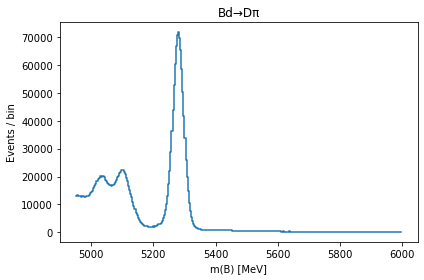

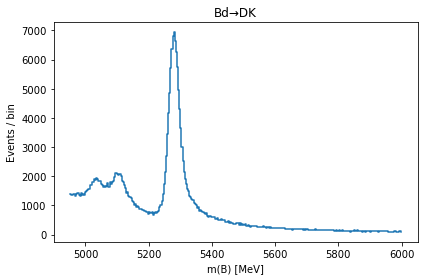

In [48]:
def quick_plot(vals, title):
    counts, edges = np.histogram(vals, bins=NBINS, range=(mmin, mmax))
    centers = 0.5*(edges[:-1] + edges[1:])
    plt.figure(figsize=(6,4))
    plt.step(centers, counts, where="mid")
    plt.xlabel("m(B) [MeV]")
    plt.ylabel("Events / bin")
    plt.title(title)
    plt.tight_layout()
    plt.show()
quick_plot(vals_Dpi, "Bd→Dπ")
quick_plot(vals_DK,  "Bd→DK")

## 4) SET UP: load pdf + histograms --> make Roo Data hist

In [49]:
print(f"[config] Using NBINS={NBINS}, mmin={mmin}, mmax={mmax} from Cell 1")
f = ROOT.TFile.Open("Bd2Dpi_DK_hists.root")
assert f and not f.IsZombie(), "Could not open Bd2Dpi_DK_hists.root"
h_Dpi = f.Get("h_Dpi")
h_DK  = f.Get("h_DK")
assert h_Dpi and h_DK, "Could not retrieve h_Dpi or h_DK from file."

# Check consistency with Cell 1 binning
assert h_Dpi.GetNbinsX() == NBINS and h_DK.GetNbinsX() == NBINS, \
    "Histogram NBINS mismatch w.r.t. Cell 1"

xmin_Dpi = h_Dpi.GetXaxis().GetXmin()
xmax_Dpi = h_Dpi.GetXaxis().GetXmax()
xmin_DK  = h_DK.GetXaxis().GetXmin()
xmax_DK  = h_DK.GetXaxis().GetXmax()

assert abs(xmin_Dpi - mmin) < 1e-3 and abs(xmax_Dpi - mmax) < 1e-3, \
    "Dpi hist mass range mismatch w.r.t. Cell 1"
assert abs(xmin_DK  - mmin) < 1e-3 and abs(xmax_DK  - mmax) < 1e-3, \
    "DK hist mass range mismatch w.r.t. Cell 1"

Ntot_Dpi = float(h_Dpi.Integral())
Ntot_DK  = float(h_DK.Integral())
print(f"Ntot_Dpi = {Ntot_Dpi:.0f}, Ntot_DK = {Ntot_DK:.0f}")

m = ROOT.RooRealVar("m", "m(B) [MeV/c^{2}]", mmin, mmax)
dh_Dpi = ROOT.RooDataHist("dh_Dpi", "Dpi binned", ROOT.RooArgList(m), h_Dpi)
dh_DK  = ROOT.RooDataHist("dh_DK",  "DK binned",  ROOT.RooArgList(m), h_DK)

[config] Using NBINS=300, mmin=4950.0, mmax=6000.0 from Cell 1
Ntot_Dpi = 1975718, Ntot_DK = 264679



## 5) Quick seeds: comb slope sign + rough (μ,σ)

#### Estimates the sign of the exponential combinatorial slope from low-mass bins.

#### Seeds a rough mean/width (μ,σ) from the peak region.

In [50]:
def seed_slope_from_hist(hist, lo, hi):
    nb = hist.GetNbinsX()
    x, y = [], []
    for i in range(1, nb+1):
        xc = hist.GetBinCenter(i)
        if lo <= xc <= hi:
            x.append(xc)
            y.append(hist.GetBinContent(i))
    x = np.array(x); y = np.array(y)
    if len(x) > 2:
        return np.polyfit(x, y, 1)[0]
    return 0.0

coef_Dpi = seed_slope_from_hist(h_Dpi, 4950, 5150)
coef_DK  = seed_slope_from_hist(h_DK,  4950, 5150)

# ---------------------------------------------------
# Seed μ, σ from both histograms
# ---------------------------------------------------
vals_all = []
for hist in (h_Dpi, h_DK):
    for i in range(1, hist.GetNbinsX()+1):
        xbin = hist.GetBinCenter(i)
        n = int(hist.GetBinContent(i))
        if n > 0:
            vals_all.extend([xbin]*n)
vals_all = np.array(vals_all, dtype=float)

focus = vals_all[(vals_all > 5200) & (vals_all < 5350)]
if focus.size > 0:
    rough, _ = np.histogram(focus, bins=80, range=(5200, 5350))
    edges = np.linspace(5200, 5350, 81)
    xmid  = 0.5*(edges[1:] + edges[:-1])
    mu0   = xmid[np.argmax(rough)]
else:
    mu0 = 5280.0

selp = vals_all[(vals_all > mu0-40) & (vals_all < mu0+40)]
sig0 = np.std(selp) if selp.size > 1 else 16.0
sig0 = float(np.clip(sig0, 12.0, 24.0))

print(f"Seed mu0 ~ {mu0:.1f}, sig0 ~ {sig0:.1f}")

Seed mu0 ~ 5281.6, sig0 ~ 16.9



## 6) Per-channel fits (Dπ, DK)

In [51]:
# STRATEGY:
#Fits Dπ and DK independently with flexible models: 
   #Signal: double-sided Crystal Ball (sum of left/right CBs).
   #Mis-ID: DK→Dπ (Gaussian) and Dπ→DK (DSCB), with peak shifts relative to μ.
   #Part-reco: HILLdini (γ-like) + HORNSdini (π⁰-like).
   #Combinatorial: exponential with slope seeded from low mass.
#Saves: fitted μ, σ (per channel) and frozen background shapes for the simultaneous fit.
#Why: two-step strategy stabilizes the later simultaneous fit by fixing shallow directions (part-reco shapes).

# JUSTIFICATION OF CHOICES:
#DSCB for signal: accommodates asymmetric radiative tails.
#Mis-ID models: DK→Dπ mostly Gaussian (narrower), Dπ→DK needs asymmetric tails → DSCB.
#HILL/HORNS: physics-motivated shapes for partially reconstructed backgrounds.
#Exponential comb: standard for random combinatorics in m(B) over a modest window.

### i) Dpi single-channel fit

In [52]:
#Builds Dπ model (signal DSCB, DK→Dπ misID Gaussian, HILL/HORNS, exponential comb).
#Fits to dh_Dpi; stores fitted values and background-shape params for later freezing.
print("\n[fit Dpi] building Dπ-only model...")
mu_Dpi_fit  = ROOT.RooRealVar("mu_Dpi_fit","mu_Dpi_fit",  mu0,  mu0-30., mu0+30.)
sig_Dpi_fit = ROOT.RooRealVar("sig_Dpi_fit","sig_Dpi_fit",sig0, 8., 30.)

# Signal DSCB tails
aL_Dpi_fit  = ROOT.RooRealVar("aL_Dpi_fit",  "aL_Dpi_fit",  1.6, 0.5, 5.0)
nL_Dpi_fit  = ROOT.RooRealVar("nL_Dpi_fit",  "nL_Dpi_fit",  4.0, 1.0, 20.0)
aR_Dpi_fit  = ROOT.RooRealVar("aR_Dpi_fit",  "aR_Dpi_fit", -2.0, -6.0, -0.5)
nR_Dpi_fit  = ROOT.RooRealVar("nR_Dpi_fit",  "nR_Dpi_fit",  3.0, 1.0, 20.0)
fLR_Dpi_fit = ROOT.RooRealVar("fLR_Dpi_fit","fLR_Dpi_fit",0.5, 0.1, 0.9)

sigL_Dpi_fit = ROOT.RooCBShape("sigL_Dpi_fit","left CB Dpi fit",
                               m, mu_Dpi_fit, sig_Dpi_fit, aL_Dpi_fit, nL_Dpi_fit)
sigR_Dpi_fit = ROOT.RooCBShape("sigR_Dpi_fit","right CB Dpi fit",
                               m, mu_Dpi_fit, sig_Dpi_fit, aR_Dpi_fit, nR_Dpi_fit)
SIG_Dpi_fit  = ROOT.RooAddPdf("SIG_Dpi_fit","DSCB Dpi fit",
                              ROOT.RooArgList(sigL_Dpi_fit, sigR_Dpi_fit),
                              ROOT.RooArgList(fLR_Dpi_fit))

# Mis-ID DK -> Dπ (Gaussian)
dMis_Dpi_fit   = ROOT.RooRealVar("dMis_Dpi_fit","DK->Dpi shift fit",45,35,55)
mu_mis_Dpi_fit = ROOT.RooFormulaVar("mu_mis_Dpi_fit","@0-@1",
                                    ROOT.RooArgList(mu_Dpi_fit,dMis_Dpi_fit))
sig_mis_Dpi_fit= ROOT.RooRealVar("sig_mis_Dpi_fit","misID width Dpi fit",
                                 max(14.0, min(20.0, sig0+2.0)), 12.0, 28.0)
MIS_Dpi_fit    = ROOT.RooGaussian("MIS_Dpi_fit","misID DK->Dpi fit",
                                  m, mu_mis_Dpi_fit, sig_mis_Dpi_fit)

# Partial-reco HILL/HORNS (independent of mu, moderate ranges)
hb_seed = mu0 - 140.0
rb_seed = mu0 -  90.0

h_a_Dpi_fit  = ROOT.RooRealVar("h_a_Dpi_fit","HILL a Dpi fit",5000,4920,5080)
#h_a_Dpi_fit  = ROOT.RooRealVar("h_a_Dpi_fit","HILL a Dpi fit",max(5000., mmin+30.), mmin+30., 5070.)
h_b_Dpi_fit  = ROOT.RooRealVar("h_b_Dpi_fit","HILL b Dpi fit",float(hb_seed),5050,5200)
h_c_Dpi_fit  = ROOT.RooRealVar("h_csi_Dpi_fit","HILL csi Dpi fit",0.45,0,1)
h_sh_Dpi_fit = ROOT.RooRealVar("h_shift_Dpi_fit","HILL shift Dpi fit",0.0,-30.,30.)
h_sg_Dpi_fit = ROOT.RooRealVar("h_sigma_Dpi_fit","HILL sigma Dpi fit",22,12,45)
h_rs_Dpi_fit = ROOT.RooRealVar("h_rs_Dpi_fit","HILL ratio_sigma Dpi fit",2.0,1.1,3.5)
h_fs_Dpi_fit = ROOT.RooRealVar("h_fs_Dpi_fit","HILL fraction_sigma Dpi fit",0.5,0.2,0.8)
BKG_g_Dpi_fit = ROOT.RooHILLdini("BKG_g_Dpi_fit","gamma-like Dpi fit",
                                 m,h_a_Dpi_fit,h_b_Dpi_fit,h_c_Dpi_fit,
                                 h_sh_Dpi_fit,h_sg_Dpi_fit,h_rs_Dpi_fit,h_fs_Dpi_fit)

r_a_Dpi_fit  = ROOT.RooRealVar("r_a_Dpi_fit","HORNS a Dpi fit",5050,4970,5150)
r_b_Dpi_fit  = ROOT.RooRealVar("r_b_Dpi_fit","HORNS b Dpi fit",float(rb_seed),5100,5250)
r_c_Dpi_fit  = ROOT.RooRealVar("r_csi_Dpi_fit","HORNS csi Dpi fit",0.30,0,1)
r_sh_Dpi_fit = ROOT.RooRealVar("r_shift_Dpi_fit","HORNS shift Dpi fit",0.0,-30.,30.)
r_sg_Dpi_fit = ROOT.RooRealVar("r_sigma_Dpi_fit","HORNS sigma Dpi fit",24,12,50)
r_rs_Dpi_fit = ROOT.RooRealVar("r_rs_Dpi_fit","HORNS ratio_sigma Dpi fit",2.0,1.1,3.5)
r_fs_Dpi_fit = ROOT.RooRealVar("r_fs_Dpi_fit","HORNS fraction_sigma Dpi fit",0.5,0.2,0.8)
BKG_pi_Dpi_fit = ROOT.RooHORNSdini("BKG_pi_Dpi_fit","pi0-like Dpi fit",
                                   m,r_a_Dpi_fit,r_b_Dpi_fit,r_c_Dpi_fit,
                                   r_sh_Dpi_fit,r_sg_Dpi_fit,r_rs_Dpi_fit,r_fs_Dpi_fit)

# Combinatorial: exponential in m (broader slope range)
tau_init_Dpi = -1e-3 if coef_Dpi <= 0 else 1e-3
tau_Dpi_fit  = ROOT.RooRealVar("tau_Dpi_fit", "exp slope Dpi fit",tau_init_Dpi, -2e-2, 0.0)
#tau_Dpi_fit = ROOT.RooRealVar("tau_Dpi_fit","exp slope Dpi fit", tau_init_Dpi, -2e-2, +2e-2)
BKG_comb_Dpi_fit = ROOT.RooExponential("BKG_comb_Dpi_fit","comb Dpi fit",
                                       m, tau_Dpi_fit)

# Yields
Nsig_Dpi_fit  = ROOT.RooRealVar("Nsig_Dpi_fit","signal yield Dπ fit",
                                0.15*Ntot_Dpi, 0.0, 2.0*Ntot_Dpi)
Nmis_Dpi_fit  = ROOT.RooRealVar("Nmis_Dpi_fit","misID yield Dπ fit",
                                0.01*Ntot_Dpi, 0.0, 0.25*Ntot_Dpi)
Ng_Dpi_fit    = ROOT.RooRealVar("Ng_Dpi_fit",  "gamma yield Dπ fit",
                                0.04*Ntot_Dpi, 0.0, 0.30*Ntot_Dpi)
Npi_Dpi_fit   = ROOT.RooRealVar("Npi_Dpi_fit", "pi0 yield Dπ fit",
                                0.01*Ntot_Dpi, 0.0, 0.20*Ntot_Dpi)
Ncomb_Dpi_fit = ROOT.RooRealVar("Ncomb_Dpi_fit","comb yield Dπ fit",
                                0.75*Ntot_Dpi, 0.0, 2.0*Ntot_Dpi)

pdf_Dpi_fit = ROOT.RooAddPdf(
    "pdf_Dpi_fit","Dπ-only model",
    ROOT.RooArgList(SIG_Dpi_fit, MIS_Dpi_fit,
                    BKG_g_Dpi_fit, BKG_pi_Dpi_fit, BKG_comb_Dpi_fit),
    ROOT.RooArgList(Nsig_Dpi_fit, Nmis_Dpi_fit,
                    Ng_Dpi_fit, Npi_Dpi_fit, Ncomb_Dpi_fit)
)

print("[fit Dpi] starting fit...")
res_Dpi = pdf_Dpi_fit.fitTo(
    dh_Dpi,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(0),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[fit Dpi] status={res_Dpi.status()}, covQual={res_Dpi.covQual()}")

mu_Dpi_val  = mu_Dpi_fit.getVal()
sig_Dpi_val = sig_Dpi_fit.getVal()
print(f"[fit Dpi] mu = {mu_Dpi_val:.3f}, sig = {sig_Dpi_val:.3f}")

bkg_shapes_Dpi = {
    "h_a": h_a_Dpi_fit.getVal(), "h_b": h_b_Dpi_fit.getVal(),
    "h_c": h_c_Dpi_fit.getVal(), "h_sh": h_sh_Dpi_fit.getVal(),
    "h_sg": h_sg_Dpi_fit.getVal(), "h_rs": h_rs_Dpi_fit.getVal(),
    "h_fs": h_fs_Dpi_fit.getVal(),
    "r_a": r_a_Dpi_fit.getVal(), "r_b": r_b_Dpi_fit.getVal(),
    "r_c": r_c_Dpi_fit.getVal(), "r_sh": r_sh_Dpi_fit.getVal(),
    "r_sg": r_sg_Dpi_fit.getVal(), "r_rs": r_rs_Dpi_fit.getVal(),
    "r_fs": r_fs_Dpi_fit.getVal(),
    "tau": tau_Dpi_fit.getVal(),
}



[fit Dpi] building Dπ-only model...
[fit Dpi] starting fit...
[fit Dpi] status=3, covQual=2
[fit Dpi] mu = 5280.732, sig = 17.382
)


[24 RooFit INFO/Eval messages suppressed for readability]


### ii) DK single-channel fit

In [53]:
#Builds DK model (signal DSCB, Dπ→DK misID DSCB, HILL/HORNS, exponential comb).
#Fits to dh_DK; stores fitted values and background-shape params.

print("\n[fit DK] building DK-only model...")

mu_DK_fit  = ROOT.RooRealVar("mu_DK_fit","mu_DK_fit",  mu0,  mu0-30., mu0+30.)
sig_DK_fit = ROOT.RooRealVar("sig_DK_fit","sig_DK_fit",sig0, 8., 30.)

aL_DK_fit  = ROOT.RooRealVar("aL_DK_fit",  "aL_DK_fit",  1.6, 0.5, 5.0)
nL_DK_fit  = ROOT.RooRealVar("nL_DK_fit",  "nL_DK_fit",  4.0, 1.0, 20.0)
aR_DK_fit  = ROOT.RooRealVar("aR_DK_fit",  "aR_DK_fit", -2.0, -6.0, -0.5)
nR_DK_fit  = ROOT.RooRealVar("nR_DK_fit",  "nR_DK_fit",  3.0, 1.0, 20.0)
fLR_DK_fit = ROOT.RooRealVar("fLR_DK_fit","fLR_DK_fit",0.5, 0.1, 0.9)

sigL_DK_fit = ROOT.RooCBShape("sigL_DK_fit","left CB DK fit",
                              m, mu_DK_fit, sig_DK_fit, aL_DK_fit, nL_DK_fit)
sigR_DK_fit = ROOT.RooCBShape("sigR_DK_fit","right CB DK fit",
                              m, mu_DK_fit, sig_DK_fit, aR_DK_fit, nR_DK_fit)
SIG_DK_fit  = ROOT.RooAddPdf("SIG_DK_fit","DSCB DK fit",
                             ROOT.RooArgList(sigL_DK_fit, sigR_DK_fit),
                             ROOT.RooArgList(fLR_DK_fit))

# Mis-ID Dπ -> DK (DSCB)
dMis_DK_fit   = ROOT.RooRealVar("dMis_DK_fit","Dpi->DK shift fit",50.0,30.0,80.0)
mu_mis_DK_fit = ROOT.RooFormulaVar("mu_mis_DK_fit","@0+@1",
                                   ROOT.RooArgList(mu_DK_fit,dMis_DK_fit))
sig_mis_DK_fit= ROOT.RooRealVar("sig_mis_DK_fit","misID width DK fit",
                                1.4*sig0, sig0, 3.0*sig0)

aL_mis_fit = ROOT.RooRealVar("aL_mis_fit","aL_mis_fit",1.5,0.5,5.0)
nL_mis_fit = ROOT.RooRealVar("nL_mis_fit","nL_mis_fit",3.0,1.0,20.0)
MIS_L_fit  = ROOT.RooCBShape("MIS_L_fit","misID left CB fit",
                             m, mu_mis_DK_fit, sig_mis_DK_fit, aL_mis_fit, nL_mis_fit)

aR_mis_fit = ROOT.RooRealVar("aR_mis_fit","aR_mis_fit",-1.5,-8.0,-0.2)
nR_mis_fit = ROOT.RooRealVar("nR_mis_fit","nR_mis_fit",3.0,1.0,20.0)
MIS_R_fit  = ROOT.RooCBShape("MIS_R_fit","misID right CB fit",
                             m, mu_mis_DK_fit, sig_mis_DK_fit, aR_mis_fit, nR_mis_fit)

fLR_mis_fit = ROOT.RooRealVar("fLR_mis_fit","frac left misID fit",0.5,0.1,0.9)
MIS_DK_fit  = ROOT.RooAddPdf("MIS_DK_fit","misID Dpi->DK fit",
                             ROOT.RooArgList(MIS_L_fit, MIS_R_fit),
                             ROOT.RooArgList(fLR_mis_fit))

# Partial-reco HILL/HORNS
h_a_DK_fit  = ROOT.RooRealVar("h_a_DK_fit","HILL a DK fit",5000,4920,5080)
#h_a_DK_fit   = ROOT.RooRealVar("h_a_DK_fit","HILL a DK fit",max(5000., mmin+30.), mmin+30., 5070.)
h_b_DK_fit  = ROOT.RooRealVar("h_b_DK_fit","HILL b DK fit",float(hb_seed),5050,5200)
h_c_DK_fit  = ROOT.RooRealVar("h_csi_DK_fit","HILL csi DK fit",0.45,0,1)
h_sh_DK_fit = ROOT.RooRealVar("h_shift_DK_fit","HILL shift DK fit",0.0,-30.,30.)
h_sg_DK_fit = ROOT.RooRealVar("h_sigma_DK_fit","HILL sigma DK fit",22,12,45)
h_rs_DK_fit = ROOT.RooRealVar("h_rs_DK_fit","HILL ratio_sigma DK fit",2.0,1.1,3.5)
h_fs_DK_fit = ROOT.RooRealVar("h_fs_DK_fit","HILL fraction_sigma DK fit",0.5,0.2,0.8)
BKG_g_DK_fit = ROOT.RooHILLdini("BKG_g_DK_fit","gamma-like DK fit",
                                m,h_a_DK_fit,h_b_DK_fit,h_c_DK_fit,
                                h_sh_DK_fit,h_sg_DK_fit,h_rs_DK_fit,h_fs_DK_fit)

r_a_DK_fit  = ROOT.RooRealVar("r_a_DK_fit","HORNS a DK fit",5050,4970,5150)
r_b_DK_fit  = ROOT.RooRealVar("r_b_DK_fit","HORNS b DK fit",float(rb_seed),5100,5250)
r_c_DK_fit  = ROOT.RooRealVar("r_csi_DK_fit","HORNS csi DK fit",0.30,0,1)
r_sh_DK_fit = ROOT.RooRealVar("r_sh_DK_fit","HORNS shift DK fit",0.0,-30.,30.)
r_sg_DK_fit = ROOT.RooRealVar("r_sigma_DK_fit","HORNS sigma DK fit",24,12,50)
r_rs_DK_fit = ROOT.RooRealVar("r_rs_DK_fit","HORNS ratio_sigma DK fit",2.0,1.1,3.5)
r_fs_DK_fit = ROOT.RooRealVar("r_fs_DK_fit","HORNS fraction_sigma DK fit",0.5,0.2,0.8)
BKG_pi_DK_fit = ROOT.RooHORNSdini("BKG_pi_DK_fit","pi0-like DK fit",
                                  m,r_a_DK_fit,r_b_DK_fit,r_c_DK_fit,
                                  r_sh_DK_fit,r_sg_DK_fit,r_rs_DK_fit,r_fs_DK_fit)

# Combinatorial: exponential in m (broader slope range)
tau_init_DK = -1e-3 if coef_DK <= 0 else 1e-3
tau_DK_fit  = ROOT.RooRealVar("tau_DK_fit","exp slope DK fit",tau_init_DK, -2e-2, 0.0)
#tau_DK_fit  = ROOT.RooRealVar("tau_DK_fit","exp slope DK fit",  tau_init_DK,  -2e-2, +2e-2)
BKG_comb_DK_fit = ROOT.RooExponential("BKG_comb_DK_fit","comb DK fit",
                                      m, tau_DK_fit)

# Yields
Nsig_DK_fit   = ROOT.RooRealVar("Nsig_DK_fit","signal yield DK fit",
                                0.35*Ntot_DK,  0.0, 2.0*Ntot_DK)
Nmis_DK_fit   = ROOT.RooRealVar("Nmis_DK_fit","misID yield DK fit",
                                0.05*Ntot_DK,  0.0, 0.5*Ntot_DK)
Ng_DK_fit     = ROOT.RooRealVar("Ng_DK_fit",  "gamma yield DK fit",
                                0.04*Ntot_DK,  0.0, 0.30*Ntot_DK)
Npi_DK_fit    = ROOT.RooRealVar("Npi_DK_fit", "pi0 yield DK fit",
                                0.02*Ntot_DK,  0.0, 0.20*Ntot_DK)
Ncomb_DK_fit  = ROOT.RooRealVar("Ncomb_DK_fit","comb yield DK fit",
                                0.54*Ntot_DK,  0.0, 2.0*Ntot_DK)

pdf_DK_fit = ROOT.RooAddPdf(
    "pdf_DK_fit","DK-only model",
    ROOT.RooArgList(SIG_DK_fit, MIS_DK_fit,
                    BKG_g_DK_fit, BKG_pi_DK_fit, BKG_comb_DK_fit),
    ROOT.RooArgList(Nsig_DK_fit, Nmis_DK_fit,
                    Ng_DK_fit, Npi_DK_fit, Ncomb_DK_fit)
)

print("[fit DK] starting fit...")
res_DK = pdf_DK_fit.fitTo(
    dh_DK,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(0),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[fit DK] status={res_DK.status()}, covQual={res_DK.covQual()}")

mu_DK_val  = mu_DK_fit.getVal()
sig_DK_val = sig_DK_fit.getVal()
print(f"[fit DK] mu = {mu_DK_val:.3f}, sig = {sig_DK_val:.3f}")

bkg_shapes_DK = {
    "h_a": h_a_DK_fit.getVal(), "h_b": h_b_DK_fit.getVal(),
    "h_c": h_c_DK_fit.getVal(), "h_sh": h_sh_DK_fit.getVal(),
    "h_sg": h_sg_DK_fit.getVal(), "h_rs": h_rs_DK_fit.getVal(),
    "h_fs": h_fs_DK_fit.getVal(),
    "r_a": r_a_DK_fit.getVal(), "r_b": r_b_DK_fit.getVal(),
    "r_c": r_c_DK_fit.getVal(), "r_sh": r_sh_DK_fit.getVal(),
    "r_sg": r_sg_DK_fit.getVal(), "r_rs": r_rs_DK_fit.getVal(),
    "r_fs": r_fs_DK_fit.getVal(),
    "tau": tau_DK_fit.getVal(),
}



[fit DK] building DK-only model...
[fit DK] starting fit...
[fit DK] status=0, covQual=2
[fit DK] mu = 5280.547, sig = 17.023
BKG_g_DK_fit_Int[m]) using numeric integrator [#RooRombergIntegrator to calculate Int(1] INFO:m)
NumericIntegration -- RooRealIntegral::init(BKG_g_DK_fit_Int[m]) using numeric integrator RooRombergIntegrator to calculate Int(m)


[23 RooFit INFO/Eval messages suppressed for readability]


## 7) Build Simultaneous model (shared μ,σ; frozen shapes; floating comb slopes)

In [54]:
#Constructs the two PDFs for the simultaneous fit with shared mu/sig.
#Freezes HILL/HORNS to 1D values; keeps comb slopes floating.
#Prepares per-channel yield parameters.

print("\n[simfit] building simultaneous model with shared μ,σ...")

mu_init  = 0.5*(mu_Dpi_val + mu_DK_val)
sig_init = 0.5*(sig_Dpi_val + sig_DK_val)

mu  = ROOT.RooRealVar("mu","shared mean",  mu_init,  mu_init-20., mu_init+20.)
sig = ROOT.RooRealVar("sig","shared sigma",sig_init, 8., 30.)

# Signal DSCB – Dπ
aL_Dpi  = ROOT.RooRealVar("aL_Dpi","aL_Dpi", aL_Dpi_fit.getVal(), 0.5, 5.0)
nL_Dpi  = ROOT.RooRealVar("nL_Dpi","nL_Dpi", nL_Dpi_fit.getVal(), 1.0,20.0)
aR_Dpi  = ROOT.RooRealVar("aR_Dpi","aR_Dpi", aR_Dpi_fit.getVal(),-6.0,-0.5)
nR_Dpi  = ROOT.RooRealVar("nR_Dpi","nR_Dpi", nR_Dpi_fit.getVal(), 1.0,20.0)
fLR_Dpi = ROOT.RooRealVar("fLR_Dpi","fLR_Dpi",fLR_Dpi_fit.getVal(),0.1,0.9)

sigL_Dpi = ROOT.RooCBShape("sigL_Dpi","left CB Dpi",
                           m, mu, sig, aL_Dpi, nL_Dpi)
sigR_Dpi = ROOT.RooCBShape("sigR_Dpi","right CB Dpi",
                           m, mu, sig, aR_Dpi, nR_Dpi)
SIG_Dpi  = ROOT.RooAddPdf("SIG_Dpi","DSCB Dpi",
                          ROOT.RooArgList(sigL_Dpi, sigR_Dpi),
                          ROOT.RooArgList(fLR_Dpi))

# Signal DSCB – DK
aL_DK  = ROOT.RooRealVar("aL_DK","aL_DK", aL_DK_fit.getVal(), 0.5, 5.0)
nL_DK  = ROOT.RooRealVar("nL_DK","nL_DK", nL_DK_fit.getVal(), 1.0,20.0)
aR_DK  = ROOT.RooRealVar("aR_DK","aR_DK", aR_DK_fit.getVal(),-6.0,-0.5)
nR_DK  = ROOT.RooRealVar("nR_DK","nR_DK", nR_DK_fit.getVal(), 1.0,20.0)
fLR_DK = ROOT.RooRealVar("fLR_DK","fLR_DK",fLR_DK_fit.getVal(),0.1,0.9)

sigL_DK = ROOT.RooCBShape("sigL_DK","left CB DK",
                          m, mu, sig, aL_DK, nL_DK)
sigR_DK = ROOT.RooCBShape("sigR_DK","right CB DK",
                          m, mu, sig, aR_DK, nR_DK)
SIG_DK  = ROOT.RooAddPdf("SIG_DK","DSCB DK",
                         ROOT.RooArgList(sigL_DK, sigR_DK),
                         ROOT.RooArgList(fLR_DK))

# Mis-ID components using shared μ
dMis_Dpi   = ROOT.RooRealVar("dMis_Dpi","DK->Dpi shift",
                             dMis_Dpi_fit.getVal(), 35., 55.)
mu_mis_Dpi = ROOT.RooFormulaVar("mu_mis_Dpi","@0-@1", ROOT.RooArgList(mu,dMis_Dpi))
sig_mis_Dpi= ROOT.RooRealVar("sig_mis_Dpi","misID width Dpi",
                             sig_mis_Dpi_fit.getVal(), 12., 28.)
MIS_Dpi    = ROOT.RooGaussian("MIS_Dpi","misID DK->Dpi", m, mu_mis_Dpi, sig_mis_Dpi)

dMis_DK   = ROOT.RooRealVar("dMis_DK","Dpi->DK shift",
                            dMis_DK_fit.getVal(), 30., 80.)
mu_mis_DK = ROOT.RooFormulaVar("mu_mis_DK","@0+@1", ROOT.RooArgList(mu,dMis_DK))
sig_mis_DK= ROOT.RooRealVar("sig_mis_DK","misID width DK",
                            sig_mis_DK_fit.getVal(), sig0, 3.0*sig0)

aL_mis = ROOT.RooRealVar("aL_mis","aL_mis", aL_mis_fit.getVal(),0.5,5.0)
nL_mis = ROOT.RooRealVar("nL_mis","nL_mis", nL_mis_fit.getVal(),1.0,20.0)
MIS_L  = ROOT.RooCBShape("MIS_L","misID left CB",
                         m, mu_mis_DK, sig_mis_DK, aL_mis, nL_mis)

aR_mis = ROOT.RooRealVar("aR_mis","aR_mis", aR_mis_fit.getVal(),-8.0,-0.2)
nR_mis = ROOT.RooRealVar("nR_mis","nR_mis", nR_mis_fit.getVal(),1.0,20.0)
MIS_R  = ROOT.RooCBShape("MIS_R","misID right CB",
                         m, mu_mis_DK, sig_mis_DK, aR_mis, nR_mis)

fLR_mis = ROOT.RooRealVar("fLR_mis","frac left misID",
                          fLR_mis_fit.getVal(),0.1,0.9)
MIS_DK  = ROOT.RooAddPdf("MIS_DK","misID Dpi->DK (DSCB)",
                         ROOT.RooArgList(MIS_L, MIS_R),
                         ROOT.RooArgList(fLR_mis))

# Frozen HILL/HORNS: Dπ
h_a_Dpi  = ROOT.RooRealVar("h_a_Dpi","HILL a Dpi", bkg_shapes_Dpi["h_a"]);  h_a_Dpi.setConstant(True)
h_b_Dpi  = ROOT.RooRealVar("h_b_Dpi","HILL b Dpi", bkg_shapes_Dpi["h_b"]);  h_b_Dpi.setConstant(True)
h_c_Dpi  = ROOT.RooRealVar("h_csi_Dpi","HILL csi Dpi",bkg_shapes_Dpi["h_c"]); h_c_Dpi.setConstant(True)
h_sh_Dpi = ROOT.RooRealVar("h_shift_Dpi","HILL shift Dpi",bkg_shapes_Dpi["h_sh"]); h_sh_Dpi.setConstant(True)
h_sg_Dpi = ROOT.RooRealVar("h_sigma_Dpi","HILL sigma Dpi",bkg_shapes_Dpi["h_sg"]); h_sg_Dpi.setConstant(True)
h_rs_Dpi = ROOT.RooRealVar("h_rs_Dpi","HILL ratio_sigma Dpi",bkg_shapes_Dpi["h_rs"]); h_rs_Dpi.setConstant(True)
h_fs_Dpi = ROOT.RooRealVar("h_fs_Dpi","HILL fraction_sigma Dpi",bkg_shapes_Dpi["h_fs"]); h_fs_Dpi.setConstant(True)
BKG_g_Dpi = ROOT.RooHILLdini("BKG_g_Dpi","gamma-like Dpi",
                             m,h_a_Dpi,h_b_Dpi,h_c_Dpi,h_sh_Dpi,h_sg_Dpi,h_rs_Dpi,h_fs_Dpi)

r_a_Dpi  = ROOT.RooRealVar("r_a_Dpi","HORNS a Dpi", bkg_shapes_Dpi["r_a"]); r_a_Dpi.setConstant(True)
r_b_Dpi  = ROOT.RooRealVar("r_b_Dpi","HORNS b Dpi", bkg_shapes_Dpi["r_b"]); r_b_Dpi.setConstant(True)
r_c_Dpi  = ROOT.RooRealVar("r_csi_Dpi","HORNS csi Dpi",bkg_shapes_Dpi["r_c"]); r_c_Dpi.setConstant(True)
r_sh_Dpi = ROOT.RooRealVar("r_sh_Dpi","HORNS shift Dpi",bkg_shapes_Dpi["r_sh"]); r_sh_Dpi.setConstant(True)
r_sg_Dpi = ROOT.RooRealVar("r_sg_Dpi","HORNS sigma Dpi",bkg_shapes_Dpi["r_sg"]); r_sg_Dpi.setConstant(True)
r_rs_Dpi = ROOT.RooRealVar("r_rs_Dpi","HORNS ratio_sigma Dpi",bkg_shapes_Dpi["r_rs"]); r_rs_Dpi.setConstant(True)
r_fs_Dpi = ROOT.RooRealVar("r_fs_Dpi","HORNS fraction_sigma Dpi",bkg_shapes_Dpi["r_fs"]); r_fs_Dpi.setConstant(True)
BKG_pi_Dpi = ROOT.RooHORNSdini("BKG_pi_Dpi","pi0-like Dpi",
                               m,r_a_Dpi,r_b_Dpi,r_c_Dpi,r_sh_Dpi,r_sg_Dpi,r_rs_Dpi,r_fs_Dpi)

# Frozen HILL/HORNS: DK
h_a_DK  = ROOT.RooRealVar("h_a_DK","HILL a DK", bkg_shapes_DK["h_a"]);  h_a_DK.setConstant(True)
h_b_DK  = ROOT.RooRealVar("h_b_DK","HILL b DK", bkg_shapes_DK["h_b"]);  h_b_DK.setConstant(True)
h_c_DK  = ROOT.RooRealVar("h_csi_DK","HILL csi DK",bkg_shapes_DK["h_c"]); h_c_DK.setConstant(True)
h_sh_DK = ROOT.RooRealVar("h_shift_DK","HILL shift DK",bkg_shapes_DK["h_sh"]); h_sh_DK.setConstant(True)
h_sg_DK = ROOT.RooRealVar("h_sigma_DK","HILL sigma DK",bkg_shapes_DK["h_sg"]); h_sg_DK.setConstant(True)
h_rs_DK = ROOT.RooRealVar("h_rs_DK","HILL ratio_sigma DK",bkg_shapes_DK["h_rs"]); h_rs_DK.setConstant(True)
h_fs_DK = ROOT.RooRealVar("h_fs_DK","HILL fraction_sigma DK",bkg_shapes_DK["h_fs"]); h_fs_DK.setConstant(True)
BKG_g_DK = ROOT.RooHILLdini("BKG_g_DK","gamma-like DK",
                            m,h_a_DK,h_b_DK,h_c_DK,h_sh_DK,h_sg_DK,h_rs_DK,h_fs_DK)

r_a_DK  = ROOT.RooRealVar("r_a_DK","HORNS a DK", bkg_shapes_DK["r_a"]); r_a_DK.setConstant(True)
r_b_DK  = ROOT.RooRealVar("r_b_DK","HORNS b DK", bkg_shapes_DK["r_b"]); r_b_DK.setConstant(True)
r_c_DK  = ROOT.RooRealVar("r_csi_DK","HORNS csi DK",bkg_shapes_DK["r_c"]); r_c_DK.setConstant(True)
r_sh_DK = ROOT.RooRealVar("r_sh_DK","HORNS shift DK",bkg_shapes_DK["r_sh"]); r_sh_DK.setConstant(True)
r_sg_DK = ROOT.RooRealVar("r_sg_DK","HORNS sigma DK",bkg_shapes_DK["r_sg"]); r_sg_DK.setConstant(True)
r_rs_DK = ROOT.RooRealVar("r_rs_DK","HORNS ratio_sigma DK",bkg_shapes_DK["r_rs"]); r_rs_DK.setConstant(True)
r_fs_DK = ROOT.RooRealVar("r_fs_DK","HORNS fraction_sigma DK",bkg_shapes_DK["r_fs"]); r_fs_DK.setConstant(True)
BKG_pi_DK = ROOT.RooHORNSdini("BKG_pi_DK","pi0-like DK",
                              m,r_a_DK,r_b_DK,r_c_DK,r_sh_DK,r_sg_DK,r_rs_DK,r_fs_DK)

# Exponential combinatorials: start from 1D-fit τ, but let them float
tau_Dpi = ROOT.RooRealVar(
    "tau_Dpi","exp slope Dpi",
    bkg_shapes_Dpi["tau"], -2e-2, 0.0
)
tau_DK = ROOT.RooRealVar(
    "tau_DK","exp slope DK",
    bkg_shapes_DK["tau"], -2e-2, 0.0
)

BKG_comb_Dpi = ROOT.RooExponential("BKG_comb_Dpi","comb Dpi", m, tau_Dpi)
BKG_comb_DK  = ROOT.RooExponential("BKG_comb_DK", "comb DK",  m, tau_DK)

# ------------------------------------------------------------------
# PID efficiencies (constants, from calibration)
# ------------------------------------------------------------------
eps_pi_pi = ROOT.RooRealVar("eps_pi_pi", "pi->pi PID eff",
                            0.905376064772922)
eps_pi_pi.setConstant(True)

eps_pi_K  = ROOT.RooRealVar("eps_pi_K",  "pi->K misID eff",
                            0.02470272025083403)
eps_pi_K.setConstant(True)

eps_K_K   = ROOT.RooRealVar("eps_K_K",   "K->K PID eff",
                            0.8545097511643245)
eps_K_K.setConstant(True)

eps_K_pi  = ROOT.RooRealVar("eps_K_pi",  "K->pi misID eff",
                            0.052326177353909764)
eps_K_pi.setConstant(True)

ratio_mis_DK  = ROOT.RooFormulaVar(
    "ratio_mis_DK",  "@0/@1", ROOT.RooArgList(eps_pi_K, eps_pi_pi)
)  # επ^K / επ^π

ratio_mis_Dpi = ROOT.RooFormulaVar(
    "ratio_mis_Dpi", "@0/@1", ROOT.RooArgList(eps_K_pi, eps_K_K)
)  # εK^π / εK^K

# ------------------------------------------------------------------
# Yields for simultaneous fit
# ------------------------------------------------------------------

# independent signal yields
Nsig_Dpi  = ROOT.RooRealVar("Nsig_Dpi","signal yield Dπ",
                            Nsig_Dpi_fit.getVal(), 0.0, 2.0*Ntot_Dpi)
Nsig_DK   = ROOT.RooRealVar("Nsig_DK","signal yield DK",
                            Nsig_DK_fit.getVal(),  0.0, 2.0*Ntot_DK)

# cross-feed yields: derived from signal yields and PID efficiencies
# Nmis_DK  = Nsig_Dpi * (επ^K / επ^π)
# Nmis_Dpi = Nsig_DK  * (εK^π / εK^K)
Nmis_DK   = ROOT.RooFormulaVar(
    "Nmis_DK",  "misID yield DK",  "@0*@1",
    ROOT.RooArgList(Nsig_Dpi, ratio_mis_DK)
)

Nmis_Dpi  = ROOT.RooFormulaVar(
    "Nmis_Dpi", "misID yield Dπ", "@0*@1",
    ROOT.RooArgList(Nsig_DK, ratio_mis_Dpi)
)

# remaining background yields are free
Ng_Dpi    = ROOT.RooRealVar("Ng_Dpi",  "gamma yield Dπ",
                            Ng_Dpi_fit.getVal(),  0.0, 0.5*Ntot_Dpi)
Npi_Dpi   = ROOT.RooRealVar("Npi_Dpi", "pi0 yield Dπ",
                            Npi_Dpi_fit.getVal(), 0.0, 0.5*Ntot_Dpi)
Ncomb_Dpi = ROOT.RooRealVar("Ncomb_Dpi","comb yield Dπ",
                            Ncomb_Dpi_fit.getVal(), 0.0, 2.0*Ntot_Dpi)

Ng_DK     = ROOT.RooRealVar("Ng_DK",  "gamma yield DK",
                            Ng_DK_fit.getVal(),    0.0, 0.5*Ntot_DK)
Npi_DK    = ROOT.RooRealVar("Npi_DK", "pi0 yield DK",
                            Npi_DK_fit.getVal(),   0.0, 0.5*Ntot_DK)
Ncomb_DK  = ROOT.RooRealVar("Ncomb_DK","comb yield DK",
                            Ncomb_DK_fit.getVal(), 0.0, 2.0*Ntot_DK)

pdf_Dpi = ROOT.RooAddPdf(
    "pdf_Dpi","Dπ model (sim)",
    ROOT.RooArgList(SIG_Dpi, MIS_Dpi, BKG_g_Dpi, BKG_pi_Dpi, BKG_comb_Dpi),
    ROOT.RooArgList(Nsig_Dpi, Nmis_Dpi, Ng_Dpi, Npi_Dpi, Ncomb_Dpi)
)

pdf_DK  = ROOT.RooAddPdf(
    "pdf_DK","DK model (sim)",
    ROOT.RooArgList(SIG_DK, MIS_DK, BKG_g_DK, BKG_pi_DK, BKG_comb_DK),
    ROOT.RooArgList(Nsig_DK, Nmis_DK, Ng_DK, Npi_DK, Ncomb_DK)
)



[simfit] building simultaneous model with shared μ,σ...



## 8) Build combined Dataset and run simultaneous fit

In [55]:
sample = ROOT.RooCategory("sample", "sample")
sample.defineType("Dpi")
sample.defineType("DK")

combData = ROOT.RooDataHist(
    "combData","combined Dπ+DK",
    ROOT.RooArgList(m),
    RF.Index(sample),
    RF.Import("Dpi", dh_Dpi),
    RF.Import("DK",  dh_DK),
)

simPdf = ROOT.RooSimultaneous("simPdf","simultaneous pdf", sample)
simPdf.addPdf(pdf_Dpi, "Dpi")
simPdf.addPdf(pdf_DK,  "DK")

print("\n[simfit] starting simultaneous fit...")
tfit = time.time()
fitres = simPdf.fitTo(
    combData,
    RF.Extended(True),
    RF.NumCPU(4),
    RF.Offset(True),
    RF.Strategy(0),
    RF.Save(True),
    RF.PrintLevel(-1),
)
print(f"[simfit] time = {time.time()-tfit:.1f}s, status={fitres.status()}, covQual={fitres.covQual()}")



[simfit] starting simultaneous fit...
[simfit] time = 0.8s, status=0, covQual=2


[58 RooFit INFO/Eval messages suppressed for readability]


## 9) Collect yields and core parameters

In [56]:
yields = {}

for name, var in [
    ("Nsig_Dpi",  Nsig_Dpi),
    ("Nmis_Dpi",  Nmis_Dpi),
    ("Ng_Dpi",    Ng_Dpi),
    ("Npi_Dpi",   Npi_Dpi),
    ("Ncomb_Dpi", Ncomb_Dpi),
    ("Nsig_DK",   Nsig_DK),
    ("Nmis_DK",   Nmis_DK),
    ("Ng_DK",     Ng_DK),
    ("Npi_DK",    Npi_DK),
    ("Ncomb_DK",  Ncomb_DK),
]:
    val = var.getVal()

    # For all RooAbsReal (RooRealVar and RooFormulaVar), you can use
    # getPropagatedError(fitres) to get the error from the covariance matrix.
    err = var.getPropagatedError(fitres)

    yields[name] = (val, err)

print("\n[simfit] yields (value ± error):")
for k in ["Nsig_Dpi","Nmis_Dpi","Ng_Dpi","Npi_Dpi","Ncomb_Dpi",
          "Nsig_DK","Nmis_DK","Ng_DK","Npi_DK","Ncomb_DK"]:
    v, e = yields[k]
    print(f"  {k:10s} = {v:10.1f} ± {e:7.1f}")
mu_val,  mu_err  = mu.getVal(),  mu.getError()
sig_val, sig_err = sig.getVal(), sig.getError()



[simfit] yields (value ± error):
  Nsig_Dpi   =   938010.2 ±  1017.3
  Nmis_Dpi   =     5502.7 ±    39.8
  Ng_Dpi     =   504066.5 ±   887.7
  Npi_Dpi    =   401565.5 ±   879.6
  Ncomb_Dpi  =   126631.1 ±  1502.9
  Nsig_DK    =    89861.0 ±   650.1
  Nmis_DK    =    25593.1 ±    27.8
  Ng_DK      =     8399.6 ±   164.9
  Npi_DK     =    55589.7 ±   306.3
  Ncomb_DK   =    85200.7 ±   544.9



## 10) Plots

Saved plot: /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png



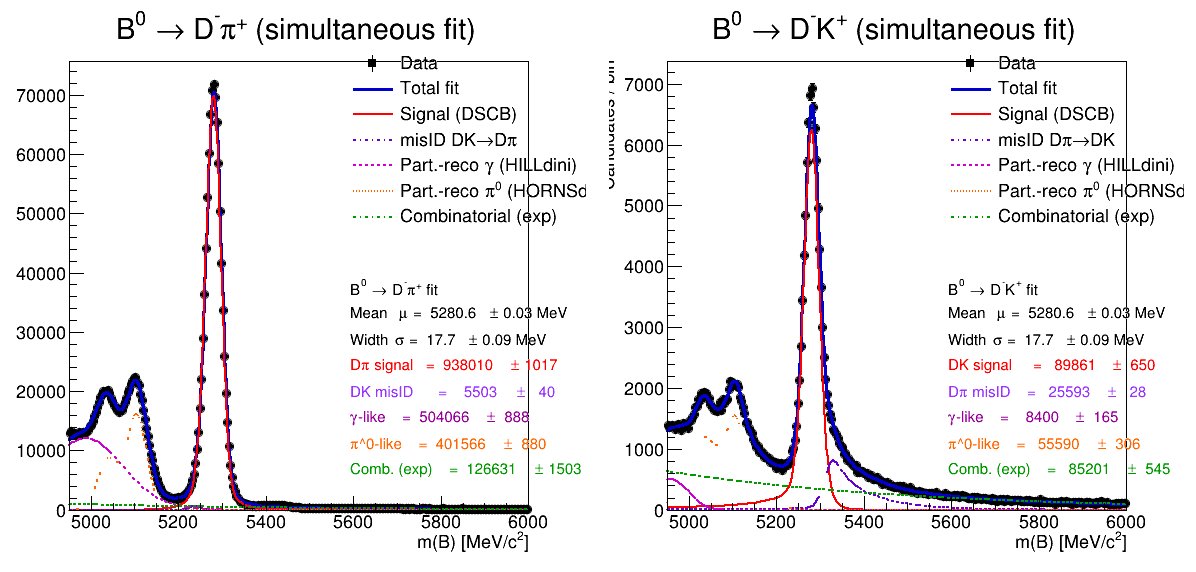



[72 RooFit INFO/Eval messages suppressed for readability]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png has been created



In [57]:
# Dπ frame
frame_Dpi = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"))
combData.plotOn(frame_Dpi, RF.Cut("sample==sample::Dpi"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kBlue+1),
              RF.Name("Dpi_total"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("SIG_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kRed),
              RF.LineWidth(2),
              RF.Name("Dpi_sig"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("MIS_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kViolet+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_mis"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_g_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kMagenta+1),
              RF.LineStyle(kDashed),
              RF.LineWidth(2),
              RF.Name("Dpi_hill"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_pi_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kOrange+7),
              RF.LineStyle(kDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_horn"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_comb_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kGreen+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_comb"))

# DK frame
frame_DK = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"))
combData.plotOn(frame_DK, RF.Cut("sample==sample::DK"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kBlue+1),
              RF.Name("DK_total"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("SIG_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kRed),
              RF.LineWidth(2),
              RF.Name("DK_sig"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("MIS_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kViolet+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("DK_mis"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_g_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kMagenta+1),
              RF.LineStyle(kDashed),
              RF.LineWidth(2),
              RF.Name("DK_hill"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_pi_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kOrange+7),
              RF.LineStyle(kDotted),
              RF.LineWidth(2),
              RF.Name("DK_horn"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_comb_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kGreen+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("DK_comb"))

# Canvas + legends + yield tables
c1 = ROOT.TCanvas("c1","Simultaneous Dπ/DK",1200,600)
c1.Divide(2,1)

# Left pad: Dπ
c1.cd(1)
frame_Dpi.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_Dpi.GetYaxis().SetTitle("Candidates / bin")
frame_Dpi.Draw()

leg1 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg1.SetFillStyle(0); leg1.SetBorderSize(0); leg1.SetTextFont(42); leg1.SetTextSize(0.035)
leg1.AddEntry(frame_Dpi.findObject("dh_Dpi"), "Data", "pe")
leg1.AddEntry(frame_Dpi.findObject("Dpi_total"), "Total fit", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_sig"),   "Signal (DSCB)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_mis"),   "misID DK#rightarrowD#pi", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_hill"),  "Part.-reco #gamma (HILLdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_horn"),  "Part.-reco #pi^{0} (HORNSdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_comb"),  "Combinatorial (exp)", "l")
leg1.Draw()

# Styled yield box for Dπ  **(moved to lower-right)**
tab1 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab1.SetFillColor(0)
tab1.SetFillStyle(0)
tab1.SetBorderSize(0)
tab1.SetTextFont(42)
tab1.SetTextSize(0.030)
tab1.SetTextAlign(12)  # left align

line = tab1.AddText("B^{0} #rightarrow D^{-}#pi^{+} fit")
line.SetTextColor(kBlack)

line = tab1.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab1.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v,e = yields["Nsig_Dpi"]
line = tab1.AddText(f"D#pi signal   = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kRed)

v,e = yields["Nmis_Dpi"]
line = tab1.AddText(f"DK misID      = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kViolet+1)

v,e = yields["Ng_Dpi"]
line = tab1.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kMagenta+2)

v,e = yields["Npi_Dpi"]
line = tab1.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kOrange+7)

v,e = yields["Ncomb_Dpi"]
line = tab1.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kGreen+2)

tab1.Draw()

# Right pad: DK
c1.cd(2)
frame_DK.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_DK.GetYaxis().SetTitle("Candidates / bin")
frame_DK.Draw()

leg2 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg2.SetFillStyle(0); leg2.SetBorderSize(0); leg2.SetTextFont(42); leg2.SetTextSize(0.035)
leg2.AddEntry(frame_DK.findObject("dh_DK"), "Data", "pe")
leg2.AddEntry(frame_DK.findObject("DK_total"), "Total fit", "l")
leg2.AddEntry(frame_DK.findObject("DK_sig"),   "Signal (DSCB)", "l")
leg2.AddEntry(frame_DK.findObject("DK_mis"),   "misID D#pi#rightarrowDK", "l")
leg2.AddEntry(frame_DK.findObject("DK_hill"),  "Part.-reco #gamma (HILLdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_horn"),  "Part.-reco #pi^{0} (HORNSdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_comb"),  "Combinatorial (exp)", "l")
leg2.Draw()

# Styled yield box for DK  **(moved to lower-right)**
tab2 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab2.SetFillColor(0)
tab2.SetFillStyle(0)
tab2.SetBorderSize(0)
tab2.SetTextFont(42)
tab2.SetTextSize(0.030)
tab2.SetTextAlign(12)

line = tab2.AddText("B^{0} #rightarrow D^{-}K^{+} fit")
line.SetTextColor(kBlack)

line = tab2.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab2.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v,e = yields["Nsig_DK"]
line = tab2.AddText(f"DK signal     = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kRed)

v,e = yields["Nmis_DK"]
line = tab2.AddText(f"D#pi misID    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kViolet+1)

v,e = yields["Ng_DK"]
line = tab2.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kMagenta+2)

v,e = yields["Npi_DK"]
line = tab2.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kOrange+7)

v,e = yields["Ncomb_DK"]
line = tab2.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}")
line.SetTextColor(kGreen+2)

tab2.Draw()

c1.Modified(); c1.Update()
ROOT.gSystem.ProcessEvents()

out_plot = "/tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled.png"
c1.SaveAs(out_plot)
print(f"Saved plot: {out_plot}")
ipydisplay(IPyImage(filename=out_plot))


## 11) Extra graphs

Saved plot: /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png



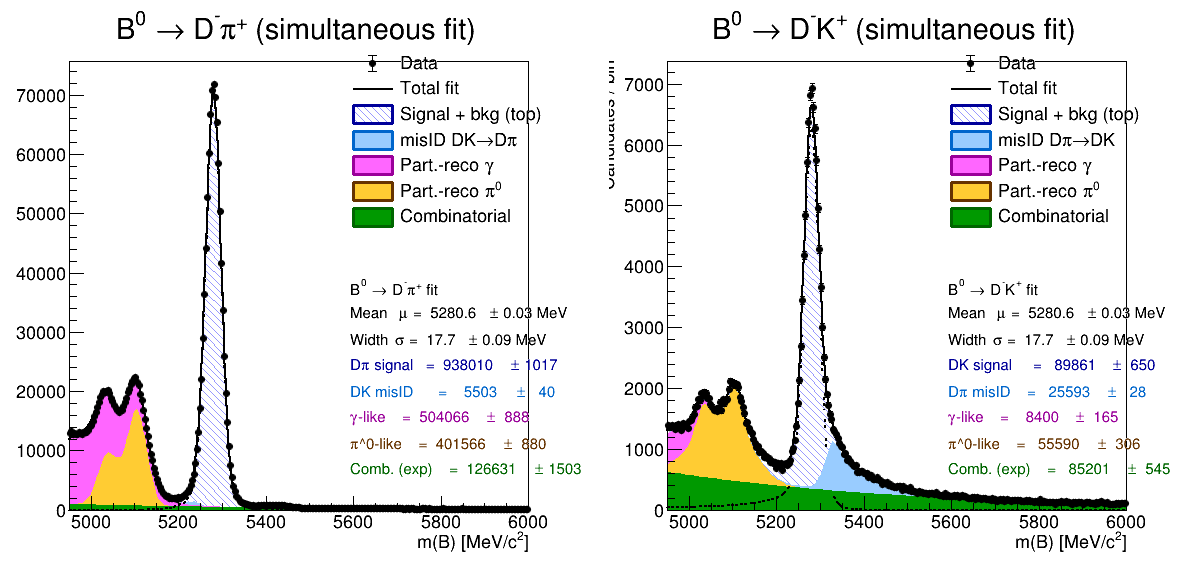



[82 RooFit INFO/Eval messages suppressed for readability]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png has been created



In [58]:
# ---------------- Dπ frame (stacked like template) ----------------
frame_Dpi = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"))

# data (Dπ slice of combData)
combData.plotOn(
    frame_Dpi,
    RF.Cut("sample==sample::Dpi"),
    RF.Name("Dpi_data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(kBlack)
)

# 1) combinatorial only (green)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi"),
    RF.Name("Dpi_comb_stack"),
    RF.FillColor(kGreen+2),
    RF.FillStyle(1001),
    RF.LineColor(kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 2) comb + pi0-like (orange)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi"),
    RF.Name("Dpi_pi0_stack"),
    RF.FillColor(kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 3) comb + pi0-like + gamma-like (magenta)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi"),
    RF.Name("Dpi_gamma_stack"),
    RF.FillColor(kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 4) comb + pi0-like + gamma-like + misID (light blue)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi,MIS_Dpi"),
    RF.Name("Dpi_mis_stack"),
    RF.FillColor(kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 5) FULL MODEL (all components, incl. signal) – top region (dark blue)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_Dpi,BKG_pi_Dpi,BKG_g_Dpi,MIS_Dpi,SIG_Dpi"),
    RF.Name("Dpi_sig_stack"),
    RF.FillColor(kBlue-9),
    RF.FillStyle(3345),  # hatched
    RF.LineColor(kBlue+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# total model line
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Name("Dpi_total"),
    RF.LineColor(kBlack),
    RF.LineWidth(2)
)

# optional signal-only line (black dashed)
simPdf.plotOn(
    frame_Dpi,
    RF.Slice(sample, "Dpi"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("SIG_Dpi"),
    RF.Name("Dpi_sig_line"),
    RF.LineColor(kBlack),
    RF.LineStyle(kDashed),
    RF.LineWidth(2)
)

# ---------------- DK frame (stacked like template) ----------------
frame_DK = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"))

combData.plotOn(
    frame_DK,
    RF.Cut("sample==sample::DK"),
    RF.Name("DK_data"),
    RF.MarkerStyle(20),
    RF.MarkerSize(0.8),
    RF.LineColor(kBlack)
)

# 1) combinatorial (green)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK"),
    RF.Name("DK_comb_stack"),
    RF.FillColor(kGreen+2),
    RF.FillStyle(1001),
    RF.LineColor(kGreen+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 2) comb + pi0-like (orange)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK"),
    RF.Name("DK_pi0_stack"),
    RF.FillColor(kOrange-2),
    RF.FillStyle(1001),
    RF.LineColor(kOrange+3),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 3) comb + pi0-like + gamma-like (magenta)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK"),
    RF.Name("DK_gamma_stack"),
    RF.FillColor(kMagenta-7),
    RF.FillStyle(1001),
    RF.LineColor(kMagenta+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 4) comb + pi0-like + gamma-like + misID (light blue)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK,MIS_DK"),
    RF.Name("DK_mis_stack"),
    RF.FillColor(kAzure-9),
    RF.FillStyle(1001),
    RF.LineColor(kAzure+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# 5) full model (dark blue top)
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("BKG_comb_DK,BKG_pi_DK,BKG_g_DK,MIS_DK,SIG_DK"),
    RF.Name("DK_sig_stack"),
    RF.FillColor(kBlue-9),
    RF.FillStyle(3345),
    RF.LineColor(kBlue+2),
    RF.DrawOption("F"),
    RF.MoveToBack()
)

# total line
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Name("DK_total"),
    RF.LineColor(kBlack),
    RF.LineWidth(2)
)

# signal-only dashed
simPdf.plotOn(
    frame_DK,
    RF.Slice(sample, "DK"),
    RF.ProjWData(ROOT.RooArgSet(sample), combData),
    RF.Components("SIG_DK"),
    RF.Name("DK_sig_line"),
    RF.LineColor(kBlack),
    RF.LineStyle(kDashed),
    RF.LineWidth(2)
)

# ---------------- Canvas + legends + yield tables ----------------
c1 = ROOT.TCanvas("c1","Simultaneous Dπ/DK",1200,600)
c1.Divide(2,1)

# Left pad: Dπ
c1.cd(1)
frame_Dpi.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_Dpi.GetYaxis().SetTitle("Candidates / bin")
frame_Dpi.SetMinimum(0)
frame_Dpi.Draw()

leg1 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg1.SetFillStyle(0); leg1.SetBorderSize(0); leg1.SetTextFont(42); leg1.SetTextSize(0.035)
leg1.AddEntry(frame_Dpi.findObject("Dpi_data"),      "Data",                   "pe")
leg1.AddEntry(frame_Dpi.findObject("Dpi_total"),     "Total fit",              "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_sig_stack"), "Signal + bkg (top)",     "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_mis_stack"), "misID DK#rightarrowD#pi","f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_gamma_stack"),"Part.-reco #gamma",     "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_pi0_stack"), "Part.-reco #pi^{0}",     "f")
leg1.AddEntry(frame_Dpi.findObject("Dpi_comb_stack"),"Combinatorial",          "f")
leg1.Draw()

# Yield box for Dπ (lower-right; same text as before)
tab1 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab1.SetFillColor(0); tab1.SetFillStyle(0); tab1.SetBorderSize(0)
tab1.SetTextFont(42); tab1.SetTextSize(0.030); tab1.SetTextAlign(12)

line = tab1.AddText("B^{0} #rightarrow D^{-}#pi^{+} fit"); line.SetTextColor(kBlack)
line = tab1.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV"); line.SetTextColor(kBlack)
line = tab1.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV"); line.SetTextColor(kBlack)

v,e = yields["Nsig_Dpi"];  line = tab1.AddText(f"D#pi signal   = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kBlue+2)
v,e = yields["Nmis_Dpi"];  line = tab1.AddText(f"DK misID      = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kAzure+2)
v,e = yields["Ng_Dpi"];    line = tab1.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kMagenta+2)
v,e = yields["Npi_Dpi"];   line = tab1.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kOrange+3)
v,e = yields["Ncomb_Dpi"]; line = tab1.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kGreen+3)
tab1.Draw()

# Right pad: DK
c1.cd(2)
frame_DK.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_DK.GetYaxis().SetTitle("Candidates / bin")
frame_DK.SetMinimum(0)
frame_DK.Draw()

leg2 = ROOT.TLegend(0.58, 0.60, 0.97, 0.92)
leg2.SetFillStyle(0); leg2.SetBorderSize(0); leg2.SetTextFont(42); leg2.SetTextSize(0.035)
leg2.AddEntry(frame_DK.findObject("DK_data"),      "Data",                   "pe")
leg2.AddEntry(frame_DK.findObject("DK_total"),     "Total fit",              "l")
leg2.AddEntry(frame_DK.findObject("DK_sig_stack"), "Signal + bkg (top)",     "f")
leg2.AddEntry(frame_DK.findObject("DK_mis_stack"), "misID D#pi#rightarrowDK","f")
leg2.AddEntry(frame_DK.findObject("DK_gamma_stack"),"Part.-reco #gamma",     "f")
leg2.AddEntry(frame_DK.findObject("DK_pi0_stack"), "Part.-reco #pi^{0}",     "f")
leg2.AddEntry(frame_DK.findObject("DK_comb_stack"),"Combinatorial",          "f")
leg2.Draw()

tab2 = ROOT.TPaveText(0.57, 0.15, 0.97, 0.52, "NDC")
tab2.SetFillColor(0); tab2.SetFillStyle(0); tab2.SetBorderSize(0)
tab2.SetTextFont(42); tab2.SetTextSize(0.030); tab2.SetTextAlign(12)

line = tab2.AddText("B^{0} #rightarrow D^{-}K^{+} fit"); line.SetTextColor(kBlack)
line = tab2.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV"); line.SetTextColor(kBlack)
line = tab2.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV"); line.SetTextColor(kBlack)

v,e = yields["Nsig_DK"];  line = tab2.AddText(f"DK signal     = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kBlue+2)
v,e = yields["Nmis_DK"];  line = tab2.AddText(f"D#pi misID    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kAzure+2)
v,e = yields["Ng_DK"];    line = tab2.AddText(f"#gamma-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kMagenta+2)
v,e = yields["Npi_DK"];   line = tab2.AddText(f"#pi^{0}-like    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kOrange+3)
v,e = yields["Ncomb_DK"]; line = tab2.AddText(f"Comb. (exp)    = {v:7.0f}  #pm {e:4.0f}"); line.SetTextColor(kGreen+3)
tab2.Draw()

c1.Modified(); c1.Update()
ROOT.gSystem.ProcessEvents()

out_plot = "/tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_stacked.png"
c1.SaveAs(out_plot)
print(f"Saved plot: {out_plot}")
ipydisplay(IPyImage(filename=out_plot))


Saved plot: /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_bothErrors.png



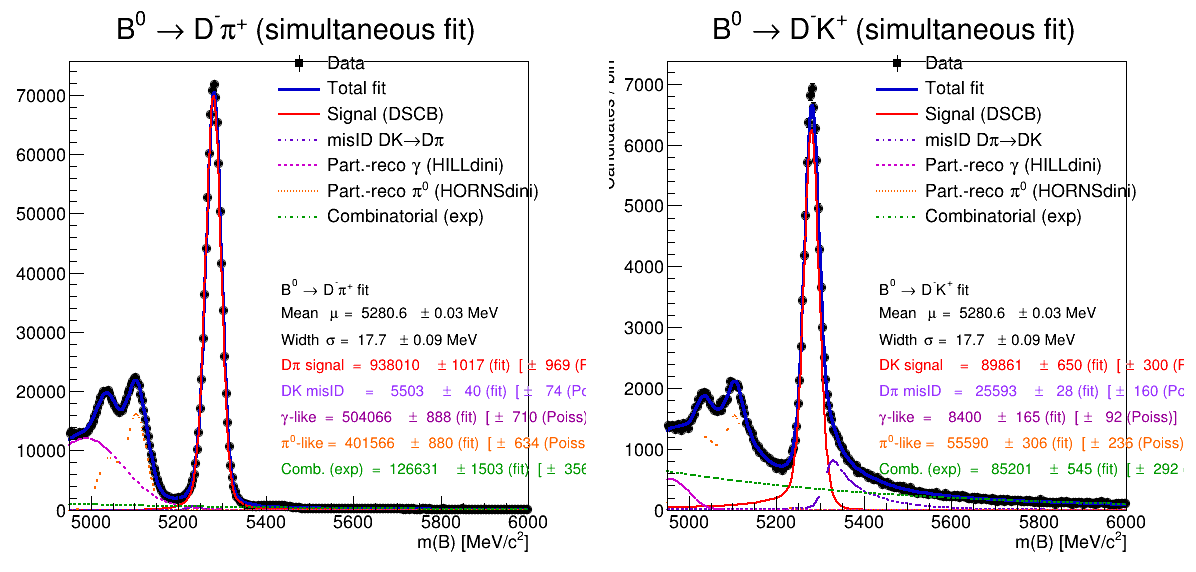



[72 RooFit INFO/Eval messages suppressed for readability]


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c1
Info in <TCanvas::Print>: png file /tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_bothErrors.png has been created



In [63]:
import math

# ------------------------------------------------------------------
# Helper: add a line with σ_fit and σ_Poisson ≈ √N
# ------------------------------------------------------------------
def add_yield_line(tab, label, v, err_fit, color):
    """
    Add a TPaveText line showing yield with both:
      - RooFit propagated error ("fit")
      - naive Poisson error sqrt(N) ("Poiss")
    """
    err_pois = math.sqrt(v) if v > 0.0 else 0.0
    line = tab.AddText(
        f"{label:<13}= {v:7.0f}  #pm {err_fit:4.0f} (fit)  "
        f"[#pm {err_pois:4.0f} (Poiss)]"
    )
    line.SetTextColor(color)
    return line


# ============================
#   Build the RooPlot frames
# ============================

# Dπ frame
frame_Dpi = m.frame(RF.Title("B^{0} #rightarrow D^{-}#pi^{+} (simultaneous fit)"))
combData.plotOn(frame_Dpi, RF.Cut("sample==sample::Dpi"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kBlue+1),
              RF.Name("Dpi_total"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("SIG_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kRed),
              RF.LineWidth(2),
              RF.Name("Dpi_sig"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("MIS_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kViolet+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_mis"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_g_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kMagenta+1),
              RF.LineStyle(kDashed),
              RF.LineWidth(2),
              RF.Name("Dpi_hill"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_pi_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kOrange+7),
              RF.LineStyle(kDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_horn"))

simPdf.plotOn(frame_Dpi,
              RF.Slice(sample, "Dpi"),
              RF.Components("BKG_comb_Dpi"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kGreen+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("Dpi_comb"))

# DK frame
frame_DK = m.frame(RF.Title("B^{0} #rightarrow D^{-}K^{+} (simultaneous fit)"))
combData.plotOn(frame_DK, RF.Cut("sample==sample::DK"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kBlue+1),
              RF.Name("DK_total"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("SIG_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kRed),
              RF.LineWidth(2),
              RF.Name("DK_sig"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("MIS_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kViolet+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("DK_mis"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_g_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kMagenta+1),
              RF.LineStyle(kDashed),
              RF.LineWidth(2),
              RF.Name("DK_hill"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_pi_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kOrange+7),
              RF.LineStyle(kDotted),
              RF.LineWidth(2),
              RF.Name("DK_horn"))

simPdf.plotOn(frame_DK,
              RF.Slice(sample, "DK"),
              RF.Components("BKG_comb_DK"),
              RF.ProjWData(ROOT.RooArgSet(sample), combData),
              RF.LineColor(kGreen+2),
              RF.LineStyle(kDashDotted),
              RF.LineWidth(2),
              RF.Name("DK_comb"))


# ===================================
#   Canvas, legends, yield tables
# ===================================

c1 = ROOT.TCanvas("c1","Simultaneous Dπ/DK",1200,600)
c1.Divide(2,1)

# ---------------
# Left pad: Dπ
# ---------------
c1.cd(1)
frame_Dpi.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_Dpi.GetYaxis().SetTitle("Candidates / bin")
frame_Dpi.Draw()

leg1 = ROOT.TLegend(0.45, 0.60, 0.85, 0.92)
leg1.SetFillStyle(0)
leg1.SetBorderSize(0)
leg1.SetTextFont(42)
leg1.SetTextSize(0.035)
leg1.AddEntry(frame_Dpi.findObject("dh_Dpi"), "Data", "pe")
leg1.AddEntry(frame_Dpi.findObject("Dpi_total"), "Total fit", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_sig"),   "Signal (DSCB)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_mis"),   "misID DK#rightarrowD#pi", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_hill"),  "Part.-reco #gamma (HILLdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_horn"),  "Part.-reco #pi^{0} (HORNSdini)", "l")
leg1.AddEntry(frame_Dpi.findObject("Dpi_comb"),  "Combinatorial (exp)", "l")
leg1.Draw()

# Styled yield box for Dπ  (lower-right)
tab1 = ROOT.TPaveText(0.45, 0.15, 0.85, 0.52, "NDC")
tab1.SetFillColor(0)
tab1.SetFillStyle(0)
tab1.SetBorderSize(0)
tab1.SetTextFont(42)
tab1.SetTextSize(0.030)
tab1.SetTextAlign(12)  # left align

line = tab1.AddText("B^{0} #rightarrow D^{-}#pi^{+} fit")
line.SetTextColor(kBlack)

line = tab1.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab1.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v, e_fit = yields["Nsig_Dpi"]
add_yield_line(tab1, "D#pi signal", v, e_fit, kRed)

v, e_fit = yields["Nmis_Dpi"]
add_yield_line(tab1, "DK misID", v, e_fit, kViolet+1)

v, e_fit = yields["Ng_Dpi"]
add_yield_line(tab1, "#gamma-like", v, e_fit, kMagenta+2)

v, e_fit = yields["Npi_Dpi"]
add_yield_line(tab1, "#pi^{0}-like", v, e_fit, kOrange+7)

v, e_fit = yields["Ncomb_Dpi"]
add_yield_line(tab1, "Comb. (exp)", v, e_fit, kGreen+2)

tab1.Draw()

# ---------------
# Right pad: DK
# ---------------
c1.cd(2)
frame_DK.GetXaxis().SetTitle("m(B) [MeV/c^{2}]")
frame_DK.GetYaxis().SetTitle("Candidates / bin")
frame_DK.Draw()

leg2 = ROOT.TLegend(0.45, 0.60, 0.85, 0.92)
leg2.SetFillStyle(0)
leg2.SetBorderSize(0)
leg2.SetTextFont(42)
leg2.SetTextSize(0.035)
leg2.AddEntry(frame_DK.findObject("dh_DK"), "Data", "pe")
leg2.AddEntry(frame_DK.findObject("DK_total"), "Total fit", "l")
leg2.AddEntry(frame_DK.findObject("DK_sig"),   "Signal (DSCB)", "l")
leg2.AddEntry(frame_DK.findObject("DK_mis"),   "misID D#pi#rightarrowDK", "l")
leg2.AddEntry(frame_DK.findObject("DK_hill"),  "Part.-reco #gamma (HILLdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_horn"),  "Part.-reco #pi^{0} (HORNSdini)", "l")
leg2.AddEntry(frame_DK.findObject("DK_comb"),  "Combinatorial (exp)", "l")
leg2.Draw()

# Styled yield box for DK  (lower-right)
tab2 = ROOT.TPaveText(0.45, 0.15, 0.85, 0.52, "NDC")
tab2.SetFillColor(0)
tab2.SetFillStyle(0)
tab2.SetBorderSize(0)
tab2.SetTextFont(42)
tab2.SetTextSize(0.030)
tab2.SetTextAlign(12)

line = tab2.AddText("B^{0} #rightarrow D^{-}K^{+} fit")
line.SetTextColor(kBlack)

line = tab2.AddText(f"Mean  #mu = {mu_val:7.1f}  #pm {mu_err:4.2f} MeV")
line.SetTextColor(kBlack)
line = tab2.AddText(f"Width #sigma = {sig_val:5.1f}  #pm {sig_err:4.2f} MeV")
line.SetTextColor(kBlack)

v, e_fit = yields["Nsig_DK"]
add_yield_line(tab2, "DK signal", v, e_fit, kRed)

v, e_fit = yields["Nmis_DK"]
add_yield_line(tab2, "D#pi misID", v, e_fit, kViolet+1)

v, e_fit = yields["Ng_DK"]
add_yield_line(tab2, "#gamma-like", v, e_fit, kMagenta+2)

v, e_fit = yields["Npi_DK"]
add_yield_line(tab2, "#pi^{0}-like", v, e_fit, kOrange+7)

v, e_fit = yields["Ncomb_DK"]
add_yield_line(tab2, "Comb. (exp)", v, e_fit, kGreen+2)

tab2.Draw()

# Finalize and save
c1.Modified()
c1.Update()
ROOT.gSystem.ProcessEvents()

out_plot = "/tmp/simfit_Bd2Dpi_DK_twoStep_exp_yieldsStyled_bothErrors.png"
c1.SaveAs(out_plot)
print(f"Saved plot: {out_plot}")
ipydisplay(IPyImage(filename=out_plot))
